# SNR-Aware CNN-LSTM MIMO Channel Estimation — Full Reproducible Pipeline

This notebook is a Google Colab-ready version of `channel_estimation_FINAL__2_.py`, prepared for the paper
**"SNR-Aware CNN-LSTM MIMO Channel Estimation."**

It is fully self-contained:
- **No external dataset is needed.** The MIMO channel data (Rayleigh-fading, temporally correlated via an AR(1)/Doppler model, with orthogonal-pilot transmission and AWGN) is **generated synthetically inside the notebook** using NumPy, exactly as in the paper's Section 2 data model.
- It trains and evaluates all baselines (LS, LMMSE, genie Kalman filter) and all deep models (CNN, LSTM, proposed SNR-aware CNN-LSTM) for **both 2×2 and 4×4 MIMO**.
- It reproduces all 12 result figures (Fig. 1–12), all CSV/LaTeX tables, and the full console log, and packages everything into a downloadable ZIP.

**How to run:** `Runtime → Change runtime type → GPU (T4 or better)`, then `Runtime → Run all`.

**Runtime note:** the full publication-grade run (`QUICK_TEST = False`, 100k training samples, 60 epochs, both MIMO sizes, plus ablation/robustness/multi-seed/seq-length studies) takes roughly **30–70 minutes on a Colab T4 GPU**. Set `QUICK_TEST = True` in the config cell for a ~3-minute smoke test that exercises the entire pipeline end-to-end (all figures/tables are still produced, just with far fewer samples/epochs — numbers won't match the paper).

## 0. Environment setup (Colab)

In [ ]:
# Colab already ships with PyTorch + CUDA. This just makes sure everything
# needed is present and prints the hardware you got.
!pip -q install --upgrade scipy >/dev/null 2>&1

import torch, sys
print("Python:", sys.version.split()[0])
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: No GPU detected. Go to Runtime -> Change runtime type -> GPU for a much faster run.")


Python: 3.12.13
Torch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## 1. Imports

In [ ]:
"""
SNR-Aware CNN-LSTM MIMO Channel Estimation -- Publication-Ready Final
================================================================================
Standalone, single-cell implementation.  All reviewer fixes applied:
  1. Explicit ORTHOGONAL PILOT model (Y_p = H X_p + N, unitary DFT X_p).
  2. Spatial correlation robustness (Kronecker model).
  3. Doppler-linked alpha = J0(2*pi*fD*Ts).
  4. Spectral efficiency vs. SNR (bug-fixed: now uses actual sweep SNR).
  5. Sequence-length study.
  6. Shaded 95% confidence intervals.
  7. Per-sample signal-power aware noise generation.
  8. Auto-generated LaTeX/CSV tables (train/test split, complexity, NMSE, BER).

Requirements:
    torch>=2.0  numpy>=1.23  matplotlib>=3.6
"""

import os
import sys
import csv
import json
import copy
import time
import random
import shutil
import platform

import numpy as np

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
except ImportError:
    sys.exit("PyTorch missing.  Run:  pip install torch numpy matplotlib")

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt



## 2. Configuration

All experiment hyperparameters live here: dataset sizes, SNR sweep, training schedule, and the two MIMO
configurations (`CONFIG_2x2`, `CONFIG_4x4`). This mirrors the paper's experimental setup exactly.

Set `QUICK_TEST = True` below for a fast smoke test; leave it `False` to reproduce the paper's numbers.

In [ ]:

# ==============================================================================
# 1. CONFIG
# ==============================================================================

QUICK_TEST = False                # True = 3-minute smoke test
RUN_SEQLEN_STUDY = True
RUN_SPATIAL_CORR_STUDY = True

_BASE = {
    'Nt': 2,
    'Nr': 2,
    'modulation': 'QPSK',
    'temporal_correlation': 0.8,
    'seq_length': 5,
    'train_samples': 100000,
    'val_samples': 20000,
    'test_samples': 20000,
    'snr_range': [0, 5, 10, 15, 20, 25, 30],
    'snr_train_range': (0, 30),
    'snr_norm_center': 15.0,
    'snr_norm_scale': 15.0,
    'batch_size': 256,
    'epochs': 60,
    'learning_rate': 1e-3,
    'patience': 10,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'seed': 42,
    'ber_channels': 256,
    'ber_bits_per_channel': 10000,
    'ber_seed': 7,
    'results_dir': './results',
    'plots_dir': './plots',
    'models_dir': './checkpoints',
    'spatial_corr_grid': [0.0, 0.3, 0.5, 0.7, 0.9],
    'spatial_corr_snr_fixed': 15,
    'seqlen_grid': [3, 5, 10],
    'seqlen_train_samples': 40000,
    'seqlen_val_samples': 8000,
}

if QUICK_TEST:
    _BASE.update({
        'train_samples': 2000, 'val_samples': 500, 'test_samples': 500,
        'epochs': 3, 'patience': 2, 'ber_channels': 32, 'ber_bits_per_channel': 2000,
        'seqlen_train_samples': 1000, 'seqlen_val_samples': 300,
    })


def make_config(tag: str, Nt: int, Nr: int) -> dict:
    cfg = copy.deepcopy(_BASE)
    cfg['Nt'], cfg['Nr'] = Nt, Nr
    cfg['tag'] = tag
    if tag:
        cfg['results_dir'] = f"{cfg['results_dir']}_{tag}"
        cfg['plots_dir'] = f"{cfg['plots_dir']}_{tag}"
        cfg['models_dir'] = f"{cfg['models_dir']}_{tag}"
    for d in (cfg['results_dir'], cfg['plots_dir'], cfg['models_dir']):
        os.makedirs(d, exist_ok=True)
    return cfg


CONFIG_2x2 = make_config('2x2', Nt=2, Nr=2)
CONFIG_4x4 = make_config('4x4', Nt=4, Nr=4)



## 3. Channel model & dataset generation

This is where the **synthetic MIMO channel dataset** is generated — there is nothing to upload or download,
it is produced on the fly by NumPy for every experiment:
- i.i.d. and spatially-correlated (Kronecker model) Rayleigh fading channels,
- AR(1) temporal evolution with Doppler-linked correlation `alpha = J0(2*pi*fD*Ts)`,
- unitary-DFT orthogonal pilot transmission and equalization,
- per-sample, SNR-calibrated AWGN.

`ChannelDataset` and `TemporalChannelDataset` are the PyTorch `Dataset` classes used for CNN and LSTM/CNN-LSTM training respectively.

In [ ]:

# ==============================================================================
# 2. CHANNEL MODEL / DATASET
# ==============================================================================

def doppler_to_alpha(fD_hz, Ts_sec):
    from numpy import pi
    try:
        from scipy.special import j0
    except ImportError:
        j0 = lambda x: 1 - (x ** 2) / 4 + (x ** 4) / 64
    return float(j0(2 * pi * fD_hz * Ts_sec))


def generate_channel_batch(batch_size, Nr, Nt):
    return (np.random.randn(batch_size, Nr, Nt)
            + 1j * np.random.randn(batch_size, Nr, Nt)) / np.sqrt(2)


def correlation_matrix(N, rho):
    idx = np.arange(N)
    R = rho ** np.abs(idx[:, None] - idx[None, :])
    R = R.astype(np.complex64)
    evals, evecs = np.linalg.eigh(R)
    evals = np.clip(evals, 0, None)
    R_sqrt = (evecs * np.sqrt(evals)) @ evecs.conj().T
    return R_sqrt.astype(np.complex64)


def generate_channel_batch_correlated(batch_size, Nr, Nt, rho_rx=0.0, rho_tx=0.0):
    W = generate_channel_batch(batch_size, Nr, Nt)
    if rho_rx == 0.0 and rho_tx == 0.0:
        return W
    Rr_sqrt = correlation_matrix(Nr, rho_rx)
    Rt_sqrt = correlation_matrix(Nt, rho_tx)
    H = np.einsum('ij,bjk,kl->bil', Rr_sqrt, W, Rt_sqrt)
    return H.astype(np.complex64)


def generate_temporal_channel_batch(batch_size, Nr, Nt, seq_length, alpha=0.8,
                                     rho_rx=0.0, rho_tx=0.0):
    H_seq = np.zeros((batch_size, seq_length, Nr, Nt), dtype=np.complex64)
    H_prev = generate_channel_batch_correlated(batch_size, Nr, Nt, rho_rx, rho_tx)
    H_seq[:, 0] = H_prev
    for t in range(1, seq_length):
        W = generate_channel_batch_correlated(batch_size, Nr, Nt, rho_rx, rho_tx)
        H_prev = alpha * H_prev + np.sqrt(1 - alpha ** 2) * W
        H_seq[:, t] = H_prev
    return H_seq


def generate_pilot_matrix(Nt):
    n = np.arange(Nt)
    Xp = np.exp(-2j * np.pi * np.outer(n, n) / Nt) / np.sqrt(Nt)
    return Xp.astype(np.complex64)


def pilot_equalize(Y_p, Xp):
    return Y_p @ Xp.conj().T


def add_noise(H, snr_db, Xp=None):
    """Pilot model + equalization.  Returns Y_eq."""
    Nt = H.shape[-1]
    if Xp is None:
        Xp = generate_pilot_matrix(Nt)
    HXp = H @ Xp
    sig_power = np.mean(np.abs(HXp) ** 2)
    noise_power = sig_power / 10 ** (snr_db / 10.0)
    noise = (np.random.randn(*H.shape) + 1j * np.random.randn(*H.shape)) * np.sqrt(noise_power / 2)
    Yp = (HXp + noise).astype(np.complex64)
    return pilot_equalize(Yp, Xp).astype(np.complex64)


# FIX: per-sample signal-power aware noise (publication correctness)
def _add_noise_per_sample(H, snr_db_array, Xp=None):
    Nt = H.shape[-1]
    if Xp is None:
        Xp = generate_pilot_matrix(Nt)
    HXp = H @ Xp
    reduce_axes = tuple(range(1, HXp.ndim))
    sig_power = np.mean(np.abs(HXp) ** 2, axis=reduce_axes, keepdims=True)
    target_shape = (H.shape[0],) + (1,) * (H.ndim - 1)
    sig_power = sig_power.reshape(target_shape)
    # snr_db_array is one value per sample (shape (batch,)); it must be reshaped
    # to (batch, 1, ..., 1) before dividing, otherwise NumPy right-aligns the
    # broadcast and silently mixes the batch axis with the last channel axis.
    snr_arr = np.asarray(snr_db_array, dtype=np.float32).reshape(target_shape)
    noise_lin = sig_power / (10 ** (snr_arr / 10.0))
    noise = np.sqrt(noise_lin / 2) * (np.random.randn(*H.shape) + 1j * np.random.randn(*H.shape))
    Yp = (HXp + noise).astype(np.complex64)
    return pilot_equalize(Yp, Xp).astype(np.complex64)


def make_snr_to_norm(center, scale):
    def snr_to_norm(snr_db):
        return (np.asarray(snr_db, dtype=np.float32) - center) / scale
    return snr_to_norm


class ChannelDataset(Dataset):
    def __init__(self, num_samples, Nt, Nr, snr_min, snr_max, snr_to_norm):
        self.H = generate_channel_batch(num_samples, Nr, Nt).astype(np.complex64)
        self.snr = np.random.uniform(snr_min, snr_max, num_samples).astype(np.float32)
        self.Y = _add_noise_per_sample(self.H, self.snr)
        self.snr_norm = snr_to_norm(self.snr)

    def __len__(self):
        return len(self.H)

    def __getitem__(self, idx):
        y, h = self.Y[idx], self.H[idx]
        y_real = np.stack([y.real, y.imag], axis=0).astype(np.float32)
        h_real = np.stack([h.real, h.imag], axis=0).astype(np.float32)
        snr_t = np.array([self.snr_norm[idx]], dtype=np.float32)
        return torch.from_numpy(y_real), torch.from_numpy(snr_t), torch.from_numpy(h_real)


class TemporalChannelDataset(Dataset):
    def __init__(self, num_samples, Nt, Nr, seq_length, snr_min, snr_max, snr_to_norm, alpha=0.8):
        self.H_seq = generate_temporal_channel_batch(num_samples, Nr, Nt, seq_length, alpha)
        self.snr = np.random.uniform(snr_min, snr_max, num_samples).astype(np.float32)
        self.Y_seq = _add_noise_per_sample(self.H_seq, self.snr)
        self.H_target = self.H_seq[:, -1]
        self.snr_norm = snr_to_norm(self.snr)

    def __len__(self):
        return len(self.H_target)

    def __getitem__(self, idx):
        y, h = self.Y_seq[idx], self.H_target[idx]
        y_real = np.stack([y.real, y.imag], axis=1).astype(np.float32)
        h_real = np.stack([h.real, h.imag], axis=0).astype(np.float32)
        snr_t = np.array([self.snr_norm[idx]], dtype=np.float32)
        return torch.from_numpy(y_real), torch.from_numpy(snr_t), torch.from_numpy(h_real)



## 4. Classical baselines: LS, LMMSE, genie Kalman filter (+ theoretical NMSE curves)

In [ ]:

# ==============================================================================
# 3. CLASSICAL BASELINES
# ==============================================================================

def ls_estimator(Y_eq):
    return Y_eq


def mmse_estimator(Y_eq, snr_db):
    """
    Wiener shrinkage for H ~ CN(0,I).  Under the i.i.d. model this is exact.
    When spatial correlation is injected (Fig9), this baseline remains
    *covariance-unaware*; a covariance-aware LMMSE is left to future work.
    """
    sigma2 = 10 ** (-snr_db / 10.0)
    return Y_eq / (1.0 + sigma2)


def kalman_estimator(Y_seq, snr_db, alpha):
    r = 10 ** (-snr_db / 10.0)
    q = 1.0 - alpha ** 2
    h_pred = np.zeros_like(Y_seq[:, 0])
    P = 1.0
    h_filt = h_pred
    for t in range(Y_seq.shape[1]):
        P_pred = alpha ** 2 * P + q
        K = P_pred / (P_pred + r)
        h_filt = h_pred + K * (Y_seq[:, t] - h_pred)
        P = (1.0 - K) * P_pred
        h_pred = alpha * h_filt
    return h_filt


def theory_ls_nmse(snr_db):
    return 10 ** (-snr_db / 10.0)


def theory_lmmse_nmse(snr_db):
    s = 10 ** (-snr_db / 10.0)
    return s / (1.0 + s)


def theory_kalman_nmse(snr_db, alpha, T):
    r, q, P = 10 ** (-snr_db / 10.0), 1 - alpha ** 2, 1.0
    for _ in range(T):
        Pp = alpha ** 2 * P + q
        K = Pp / (Pp + r)
        P = (1 - K) * Pp
    return P



## 5. Deep estimators: CNN, LSTM, proposed SNR-aware CNN-LSTM (+ no-gate ablation variant)

In [ ]:

# ==============================================================================
# 4. DEEP ESTIMATORS
# ==============================================================================

class CNNEstimator(nn.Module):
    def __init__(self, Nr=2, Nt=2):
        super().__init__()
        self.Nr, self.Nt = Nr, Nt
        self.conv1 = nn.Conv2d(2, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(8)
        self.snr_gate = nn.Linear(1, 8)
        self.fc1 = nn.Linear(8 * Nr * Nt, 16)
        self.fc2 = nn.Linear(16, 2 * Nr * Nt)
        self.relu = nn.ReLU()

    def forward(self, y, snr_norm):
        x = self.relu(self.bn1(self.conv1(y)))
        x = self.relu(self.bn2(self.conv2(x)))
        gate = torch.sigmoid(self.snr_gate(snr_norm)).view(-1, 8, 1, 1)
        x = x * gate
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return self.fc2(x).view(-1, 2, self.Nr, self.Nt)


class LSTMEstimator(nn.Module):
    def __init__(self, Nr=2, Nt=2, seq_length=5, hidden_size=32):
        super().__init__()
        self.Nr, self.Nt, self.seq_length = Nr, Nt, seq_length
        self.lstm = nn.LSTM(2 * Nr * Nt, hidden_size, batch_first=True)
        self.snr_gate = nn.Linear(1, hidden_size)
        self.fc1 = nn.Linear(hidden_size, 16)
        self.fc2 = nn.Linear(16, 2 * Nr * Nt)
        self.relu = nn.ReLU()

    def forward(self, y_seq, snr_norm):
        B = y_seq.size(0)
        x = y_seq.view(B, self.seq_length, -1)
        _, (h_n, _) = self.lstm(x)
        gate = torch.sigmoid(self.snr_gate(snr_norm))
        h = h_n[-1] * gate
        x = self.relu(self.fc1(h))
        return self.fc2(x).view(-1, 2, self.Nr, self.Nt)


class CNNLSTMEstimator(nn.Module):
    def __init__(self, Nr=2, Nt=2, seq_length=5, hidden_size=32):
        super().__init__()
        self.Nr, self.Nt, self.seq_length = Nr, Nt, seq_length
        self.conv1 = nn.Conv2d(2, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(8)
        self.relu = nn.ReLU()
        self.lstm = nn.LSTM(8 * Nr * Nt, hidden_size, batch_first=True)
        self.snr_gate = nn.Linear(1, hidden_size)
        self.fc1 = nn.Linear(hidden_size, 16)
        self.fc2 = nn.Linear(16, 2 * Nr * Nt)

    def forward(self, y_seq, snr_norm):
        B, T = y_seq.size(0), y_seq.size(1)
        x = y_seq.reshape(B * T, *y_seq.shape[2:])
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = x.view(B, T, -1)
        _, (h_n, _) = self.lstm(x)
        gate = torch.sigmoid(self.snr_gate(snr_norm))
        h = h_n[-1] * gate
        x = self.relu(self.fc1(h))
        return self.fc2(x).view(-1, 2, self.Nr, self.Nt)


class CNNLSTMEstimatorNoGate(nn.Module):
    def __init__(self, Nr=2, Nt=2, seq_length=5, hidden_size=32):
        super().__init__()
        self.Nr, self.Nt, self.seq_length = Nr, Nt, seq_length
        self.conv1 = nn.Conv2d(2, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(8)
        self.relu = nn.ReLU()
        self.lstm = nn.LSTM(8 * Nr * Nt, hidden_size, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, 16)
        self.fc2 = nn.Linear(16, 2 * Nr * Nt)

    def forward(self, y_seq, snr_norm):
        B, T = y_seq.size(0), y_seq.size(1)
        x = y_seq.reshape(B * T, *y_seq.shape[2:])
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = x.view(B, T, -1)
        _, (h_n, _) = self.lstm(x)
        x = self.relu(self.fc1(h_n[-1]))
        return self.fc2(x).view(-1, 2, self.Nr, self.Nt)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def count_flops(name, Nr=2, Nt=2, T=5, hidden=32):
    conv = lambda ci, co, k, ho, wo: 2 * ho * wo * co * ci * k * k
    lin = lambda i, o: 2 * i * o
    core = conv(2, 16, 3, Nr, Nt) + conv(16, 8, 3, Nr, Nt)
    snr_gate_cnn = lin(1, 8)
    snr_gate_seq = lin(1, hidden)
    head = lambda h: lin(h, 16) + lin(16, 2 * Nr * Nt)
    lstm = lambda ins: T * (2 * 4 * hidden * (ins + hidden)) + head(hidden)
    if name == 'cnn':
        return core + snr_gate_cnn + head(8 * Nr * Nt)
    if name == 'lstm':
        return lstm(2 * Nr * Nt) + snr_gate_seq
    if name == 'cnn_lstm':
        return T * core + lstm(8 * Nr * Nt) + snr_gate_seq
    raise ValueError(name)



## 6. Training loop, latency measurement utilities

In [ ]:

# ==============================================================================
# 5. TRAINING
# ==============================================================================

def train_model(model, train_loader, val_loader, device, epochs, lr, patience,
                 model_name, models_dir):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    best_val, wait = float('inf'), 0
    history = {'train_loss': [], 'val_loss': []}
    t0 = time.time()
    best_path = f"{models_dir}/{model_name}_best.pt"

    for epoch in range(epochs):
        model.train()
        tr = 0.0
        for y, snr, h in train_loader:
            y, snr, h = y.to(device), snr.to(device), h.to(device)
            optimizer.zero_grad()
            loss = criterion(model(y, snr), h)
            loss.backward()
            optimizer.step()
            tr += loss.item() * y.size(0)
        tr /= len(train_loader.dataset)

        model.eval()
        va = 0.0
        with torch.no_grad():
            for y, snr, h in val_loader:
                y, snr, h = y.to(device), snr.to(device), h.to(device)
                va += criterion(model(y, snr), h).item() * y.size(0)
        va /= len(val_loader.dataset)

        history['train_loss'].append(tr)
        history['val_loss'].append(va)
        scheduler.step(va)

        if va < best_val:
            best_val, wait = va, 0
            cpu_state = {k: v.cpu() for k, v in model.state_dict().items()}
            torch.save(cpu_state, best_path)
        else:
            wait += 1
            if wait >= patience:
                break

    train_time = time.time() - t0
    model.load_state_dict(torch.load(best_path, map_location='cpu'))
    model.to(device)
    model.eval()
    return history, train_time


def to_real2(Y):
    return np.stack([Y.real, Y.imag], axis=1).astype(np.float32)


def seq_to_real2(Y_seq):
    return np.stack([Y_seq.real, Y_seq.imag], axis=2).astype(np.float32)


@torch.no_grad()
def predict_complex(model, X_real, snr_db, device, snr_to_norm, bs=4096):
    model.eval()
    N = len(X_real)
    snr_arr = np.full(N, snr_db, dtype=np.float32) if np.isscalar(snr_db) else np.asarray(snr_db, dtype=np.float32)
    snr_norm = snr_to_norm(snr_arr).reshape(-1, 1)
    outs = []
    for i in range(0, N, bs):
        xb = torch.from_numpy(X_real[i:i + bs]).to(device)
        sb = torch.from_numpy(snr_norm[i:i + bs]).to(device)
        outs.append(model(xb, sb).cpu().numpy())
    Hr = np.concatenate(outs)
    return Hr[:, 0] + 1j * Hr[:, 1]


def measure_inference_latency_ms(fn, num_trials=500):
    for _ in range(10):
        fn()
    t0 = time.time()
    for _ in range(num_trials):
        fn()
    return (time.time() - t0) / num_trials * 1000.0


@torch.no_grad()
def measure_dl_latency_ms(model, device, sample_input, sample_snr, num_trials=500):
    model.eval()
    x = sample_input.to(device)
    s = sample_snr.to(device)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    for _ in range(10):
        model(x, s)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(num_trials):
        model(x, s)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    return (time.time() - t0) / num_trials * 1000.0



## 7. Metrics: NMSE with 95% CI, paired BER (QPSK + ZF equalizer)

In [ ]:

# ==============================================================================
# 6. METRICS
# ==============================================================================

def qpsk_modulate(bits):
    symbols = (2 * bits[:, 0::2].astype(np.int32) - 1) + 1j * (2 * bits[:, 1::2].astype(np.int32) - 1)
    return symbols / np.sqrt(2)


def qpsk_demodulate(symbols):
    bits = np.zeros((symbols.shape[0], symbols.shape[1] * 2), dtype=np.int64)
    bits[:, 0::2] = (np.real(symbols) > 0)
    bits[:, 1::2] = (np.imag(symbols) > 0)
    return bits


def nmse_with_ci(H_true, H_est):
    err = np.sum(np.abs(H_true - H_est) ** 2, axis=(1, 2))
    ref = np.sum(np.abs(H_true) ** 2, axis=(1, 2))
    per = err / np.maximum(ref, 1e-12)
    if len(per) > 1:
        ci = 1.96 * per.std(ddof=1) / np.sqrt(len(per))
    else:
        ci = 0.0
    return float(per.mean()), float(ci)


def paired_ber(H_true, H_est_dict, snr_db, num_bits=10000):
    C, Nr, Nt = H_true.shape
    snr_lin = 10 ** (snr_db / 10.0)
    Tf = (num_bits // 2) // Nt
    bits = np.random.randint(0, 2, (C, Tf * Nt * 2))
    sym = qpsk_modulate(bits)
    X = sym.reshape(C, Tf, Nt).transpose(0, 2, 1)
    Y = H_true @ X
    noise_power = np.mean(np.abs(Y) ** 2) / snr_lin
    Y = Y + (np.random.randn(*Y.shape) + 1j * np.random.randn(*Y.shape)) * np.sqrt(noise_power / 2)
    out, nbits = {}, bits.size
    for name, He in H_est_dict.items():
        Hh = He.conj().transpose(0, 2, 1)
        G = Hh @ He + 1e-8 * np.eye(Nt)
        Xe = np.linalg.solve(G, Hh @ Y)
        xe = Xe.transpose(0, 2, 1).reshape(C, -1)
        b = qpsk_demodulate(xe)
        p = float(np.mean(b != bits))
        ci = 1.96 * np.sqrt(max(p * (1 - p), 1e-15) / nbits)
        out[name] = {'ber': p, 'ber_ci95': float(ci), 'nbits': int(nbits)}
    return out



## 8. CSV / LaTeX export helpers (for the paper's tables)

In [ ]:

# ==============================================================================
# 7. CSV / LaTeX EXPORT HELPERS
# ==============================================================================

def write_json(path, obj):
    with open(path, 'w') as f:
        json.dump(obj, f, indent=2)


def write_nmse_ber_latex(path, SNRS, methods, allm, nmse_results, ber_results):
    tex = []
    tex.append("% ---- NMSE table ----")
    tex.append("\\begin{table}[t]\\centering\\caption{NMSE vs. SNR ($^\\dagger$genie bound).}"
                "\\label{tab:nmse}\\begin{tabular}{l" + "c" * len(methods) + "}\\toprule")
    tex.append("SNR (dB) & " + " & ".join(m.replace(' (genie)', '$^\\dagger$') for m in methods) + r" \\")
    tex.append("\\midrule")
    for s in SNRS:
        vals = {m: nmse_results[m][s][0] for m in methods}
        best = min(vals[m] for m in ['CNN', 'LSTM', 'CNN-LSTM'])
        row = []
        for m in methods:
            v = f"{vals[m]:.4f}"
            row.append(f"\\textbf{{{v}}}" if vals[m] == best and m in ['CNN', 'LSTM', 'CNN-LSTM'] else v)
        tex.append(" & ".join([str(s)] + row) + r" \\")
    tex.append("\\bottomrule\\end{tabular}\\end{table}")

    tex.append("% ---- BER table ----")
    tex.append("\\begin{table}[t]\\centering\\caption{BER vs. SNR (QPSK, ZF equalizer; $^\\dagger$bound).}"
                "\\label{tab:ber}\\begin{tabular}{l" + "c" * len(allm) + "}\\toprule")
    tex.append("SNR (dB) & " + " & ".join(
        m.replace(' (genie)', '$^\\dagger$').replace('Perfect CSI', 'Perfect CSI$^\\dagger$') for m in allm) + r" \\")
    tex.append("\\midrule")
    for s in SNRS:
        vals = [f"{ber_results[m][s]['ber']:.2e}" for m in allm]
        tex.append(" & ".join([str(s)] + vals) + r" \\")
    tex.append("\\bottomrule\\end{tabular}\\end{table}")

    with open(path, 'w') as f:
        f.write("\n".join(tex))
    return tex


def write_complexity_csv(path, params, flops, train_times, lat, lcpu, ldev):
    rows = [
        ['Method', 'Parameters', 'FLOPs', 'Train_time_s', 'Latency_CPU_ms', 'Latency_device_ms'],
        ['LS', '-', '-', '-', f"{lat['LS']:.4f}", '-'],
        ['LMMSE', '-', '-', '-', f"{lat['LMMSE']:.4f}", '-'],
        ['Kalman (genie)', '-', '-', '-', f"{lat['Kalman (genie)']:.4f}", '-'],
    ]
    for name, key in [('CNN', 'cnn'), ('LSTM', 'lstm'), ('CNN-LSTM', 'cnn_lstm')]:
        rows.append([name, params[name], flops[key], f"{train_times[name]:.2f}",
                     f"{lcpu[name]:.4f}", f"{ldev[name]:.4f}"])
    with open(path, 'w', newline='') as f:
        csv.writer(f).writerows(rows)


# FIX: complexity LaTeX table
def write_complexity_latex(path, params, flops, train_times, lat, lcpu, ldev):
    tex = [
        "",
        "% ---- Complexity comparison table ----",
        "\\begin{table}[t]\\centering\\caption{Model complexity and inference latency.}",
        "\\label{tab:complexity}\\begin{tabular}{lcccc}\\toprule",
        "Method & Parameters & FLOPs & Latency (CPU, ms) & Latency (Device, ms) \\\\",
        "\\midrule",
    ]
    for classic in ['LS', 'LMMSE', 'Kalman (genie)']:
        tex.append(f"{classic} & -- & -- & {lat[classic]:.4f} & -- \\\\")
    for name, key in [('CNN', 'cnn'), ('LSTM', 'lstm'), ('CNN-LSTM', 'cnn_lstm')]:
        tex.append(f"{name} & {params[name]:,} & {flops[key]:,} & {lcpu[name]:.4f} & {ldev[name]:.4f} \\\\")
    tex.append("\\bottomrule\\end{tabular}\\end{table}")
    with open(path, 'a') as f:
        f.write("\n".join(tex))


def write_training_history_csv(path, histories):
    rows = [['model', 'epoch', 'train_loss', 'val_loss']]
    for name, hist in histories:
        for epoch, (tr, va) in enumerate(zip(hist['train_loss'], hist['val_loss']), start=1):
            rows.append([name, epoch, tr, va])
    with open(path, 'w', newline='') as f:
        csv.writer(f).writerows(rows)


# FIX: explicit train/test split table
def write_train_test_split_csv(path, cfg):
    rows = [
        ['Parameter', 'Value'],
        ['Training samples', cfg['train_samples']],
        ['Validation samples', cfg['val_samples']],
        ['Testing samples', cfg['test_samples']],
        ['Sequence length', cfg['seq_length']],
        ['SNR range (dB)', f"{cfg['snr_range'][0]}--{cfg['snr_range'][-1]}" if isinstance(cfg['snr_range'], list) else str(cfg['snr_range'])],
        ['SNR training range (dB)', f"{cfg['snr_train_range'][0]}--{cfg['snr_train_range'][1]}"],
        ['Optimizer', 'Adam'],
        ['Learning rate', cfg['learning_rate']],
        ['Epochs (max)', cfg['epochs']],
        ['Early-stopping patience', cfg['patience']],
        ['Batch size', cfg['batch_size']],
        ['Random seed', cfg['seed']],
        ['Pilot design', 'Unitary DFT (Xp Xp^H = I)'],
    ]
    with open(path, 'w', newline='') as f:
        csv.writer(f).writerows(rows)


def write_final_table(csv_path, tex_path_append, SNRS, methods, params, nmse_results, ber_results, final_snr=20):
    assert final_snr in SNRS
    rows = [['Model', f'NMSE@{final_snr}dB', f'BER@{final_snr}dB', 'Parameters']]
    for m in methods:
        rows.append([m, f"{nmse_results[m][final_snr][0]:.4f}",
                     f"{ber_results[m][final_snr]['ber']:.3e}", params.get(m, '-')])
    with open(csv_path, 'w', newline='') as f:
        csv.writer(f).writerows(rows)

    tex = ["", "% ---- Final summary table ----",
           "\\begin{table}[t]\\centering\\caption{Summary at SNR=%d~dB. "
           "``CNN-LSTM'' is the proposed SNR-aware CNN-LSTM.}"
           "\\label{tab:final}\\begin{tabular}{lccc}\\toprule" % final_snr,
           r"Model & NMSE & BER & Parameters \\", "\\midrule"]
    for m in methods:
        p = params.get(m, '-')
        p_str = f"{p:,}" if isinstance(p, int) else p
        name = m.replace(' (genie)', '$^\\dagger$').replace('CNN-LSTM', 'Proposed CNN-LSTM')
        tex.append(f"{name} & {nmse_results[m][final_snr][0]:.4f} & "
                    f"{ber_results[m][final_snr]['ber']:.2e} & {p_str} " + r"\\")
    tex.append("\\bottomrule\\end{tabular}\\end{table}")

    with open(tex_path_append, 'a') as f:
        f.write("\n".join(tex))
    return rows, tex


def write_experiment_comparison_csv(path, SNRS, nmse_a, nmse_b, ber_a, ber_b, method='CNN-LSTM'):
    rows = [['SNR_dB', 'NMSE_A', 'NMSE_B', 'BER_A', 'BER_B']]
    for s in SNRS:
        rows.append([s, f"{nmse_a[method][s][0]:.4f}", f"{nmse_b[method][s][0]:.4f}",
                     f"{ber_a[method][s]['ber']:.3e}", f"{ber_b[method][s]['ber']:.3e}"])
    with open(path, 'w', newline='') as f:
        csv.writer(f).writerows(rows)


def write_simulation_parameters_csv(path, cfg):
    rows = [['Parameter', 'Value']]
    interesting = ['tag', 'Nt', 'Nr', 'modulation', 'temporal_correlation', 'seq_length',
                   'train_samples', 'val_samples', 'test_samples', 'snr_range', 'snr_train_range',
                   'batch_size', 'epochs', 'learning_rate', 'patience', 'seed',
                   'ber_channels', 'ber_bits_per_channel', 'spatial_corr_grid', 'seqlen_grid',
                   'device']
    for k in interesting:
        if k in cfg:
            rows.append([k, cfg[k]])
    rows.append(['pilot_matrix', 'unitary DFT, Xp @ Xp^H = I'])
    rows.append(['CNN', 'Conv2d(2,16,3)-BN-ReLU-Conv2d(16,8,3)-BN-ReLU'])
    rows.append(['LSTM_hidden_size', 32])
    rows.append(['SNR_conditioning', 'sigmoid FiLM-style gate on LSTM/CNN features'])
    with open(path, 'w', newline='') as f:
        csv.writer(f).writerows(rows)



## 9. Figure-generation functions (Fig. 1–12)

In [ ]:

# ==============================================================================
# 8. FIGURES
# ==============================================================================

MARKERS = {'LS': 'o-', 'LMMSE': 's-', 'Kalman (genie)': 'x--', 'CNN': '^-',
           'LSTM': 'd-', 'CNN-LSTM': 'p-', 'Perfect CSI': 'k--'}
LABELS = {'CNN-LSTM': 'Proposed CNN-LSTM'}


def plot_nmse_vs_snr(path, SNRS, methods, nmse_results, ALPHA, T):
    fig, ax = plt.subplots(figsize=(8, 6))
    # analytical curves (light) -- distinct labels so readers know which is which
    ax.semilogy(SNRS, [theory_ls_nmse(s) for s in SNRS], ':', color='lightgray', linewidth=1.2, label='Theory (LS)')
    ax.semilogy(SNRS, [theory_lmmse_nmse(s) for s in SNRS], '--', color='lightgray', linewidth=1.2, label='Theory (LMMSE)')
    ax.semilogy(SNRS, [theory_kalman_nmse(s, ALPHA, T) for s in SNRS], '-.', color='lightgray', linewidth=1.2, label='Theory (KF)')
    for m in methods:
        means = np.array([nmse_results[m][s][0] for s in SNRS])
        cis = np.array([nmse_results[m][s][1] for s in SNRS])
        line, = ax.semilogy(SNRS, means, MARKERS[m], label=LABELS.get(m, m), linewidth=2)
        lo = np.clip(means - cis, 1e-12, None)
        ax.fill_between(SNRS, lo, means + cis, color=line.get_color(), alpha=0.15, linewidth=0)
    ax.set_xlabel('SNR (dB)'); ax.set_ylabel('NMSE')
    ax.set_title('NMSE vs. SNR (shaded: 95% CI)')
    ax.legend(fontsize=8); ax.grid(True, which='both', ls='--', alpha=0.7)
    plt.tight_layout(); plt.savefig(path, dpi=300, bbox_inches='tight'); plt.close(fig)


def plot_ber_vs_snr(path, SNRS, allm, ber_results):
    fig, ax = plt.subplots(figsize=(8, 6))
    for m in allm:
        ax.semilogy(SNRS, [ber_results[m][s]['ber'] for s in SNRS], MARKERS[m], label=LABELS.get(m, m), linewidth=2)
    ax.set_xlabel('SNR (dB)'); ax.set_ylabel('BER (QPSK, ZF)')
    ax.legend(); ax.grid(True, which='both', ls='--', alpha=0.7)
    plt.tight_layout(); plt.savefig(path, dpi=300, bbox_inches='tight'); plt.close(fig)


def plot_training_curves(path, hist_cnn, hist_lstm, hist_cnnlstm):
    fig, ax = plt.subplots(figsize=(8, 6))
    for hists, name in [(hist_cnn, 'CNN'), (hist_lstm, 'LSTM'), (hist_cnnlstm, 'CNN-LSTM')]:
        ax.plot(hists['val_loss'], label=f'{name} (val)', linewidth=2)
        ax.plot(hists['train_loss'], '--', alpha=0.5, label=f'{name} (train)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE loss'); ax.set_yscale('log')
    ax.legend(); ax.grid(True, ls='--', alpha=0.7)
    plt.tight_layout(); plt.savefig(path, dpi=300, bbox_inches='tight'); plt.close(fig)


def plot_ablation(path, SNRS, gate_ablation):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.semilogy(SNRS, [gate_ablation[s]['with_gate_nmse'] for s in SNRS], 'p-',
                label='CNN-LSTM (with SNR-gate, proposed)', linewidth=2)
    ax.semilogy(SNRS, [gate_ablation[s]['no_gate_nmse'] for s in SNRS], 'x--',
                label='CNN-LSTM (no SNR-gate, ablation)', linewidth=2)
    ax.set_xlabel('SNR (dB)'); ax.set_ylabel('NMSE')
    ax.set_title('Ablation: effect of SNR-aware gating')
    ax.legend(); ax.grid(True, which='both', ls='--', alpha=0.7)
    plt.tight_layout(); plt.savefig(path, dpi=300, bbox_inches='tight'); plt.close(fig)


def plot_robustness(path, alpha_grid, mismatch_results, ALPHA, SNR_FIXED):
    fig, ax = plt.subplots(figsize=(8, 6))
    methods_m = list(mismatch_results[alpha_grid[0]].keys())
    mk_m = {'LS': 'o-', 'LMMSE': 's-', 'Kalman (genie, true alpha)': 'x--',
            'LSTM (trained @ alpha=0.8)': 'd-', 'CNN-LSTM (trained @ alpha=0.8)': 'p-'}
    for m in methods_m:
        ax.plot(alpha_grid, [mismatch_results[a][m] for a in alpha_grid], mk_m.get(m, 'o-'), label=m, linewidth=2)
    ax.axvline(ALPHA, color='gray', ls=':', alpha=0.7, label=f'Training alpha ({ALPHA})')
    ax.set_xlabel(r'Test-time temporal correlation $\alpha$'); ax.set_ylabel('NMSE')
    ax.set_title(f'Robustness to temporal-correlation mismatch (SNR={SNR_FIXED} dB)')
    ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.7)
    plt.tight_layout(); plt.savefig(path, dpi=300, bbox_inches='tight'); plt.close(fig)


def plot_multiseed(path, SNRS, seed_summary):
    fig, ax = plt.subplots(figsize=(8, 6))
    means = [seed_summary[s]['mean'] for s in SNRS]
    stds = [seed_summary[s]['std'] for s in SNRS]
    n_seeds = seed_summary[SNRS[0]]['seeds_n']
    ax.errorbar(SNRS, means, yerr=stds, fmt='p-', capsize=4, linewidth=2,
                label=f'CNN-LSTM (n={n_seeds} seeds)')
    ax.set_yscale('log')
    ax.set_xlabel('SNR (dB)'); ax.set_ylabel('NMSE (mean +/- std)')
    ax.set_title('Multi-seed variance of the proposed CNN-LSTM')
    ax.legend(); ax.grid(True, which='both', ls='--', alpha=0.7)
    plt.tight_layout(); plt.savefig(path, dpi=300, bbox_inches='tight'); plt.close(fig)


def plot_2x2_vs_4x4(path, SNRS, nmse_2x2, nmse_4x4):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.semilogy(SNRS, [nmse_2x2['CNN-LSTM'][s][0] for s in SNRS], 'p-',
                label='Proposed CNN-LSTM (2x2, Experiment A)', linewidth=2)
    ax.semilogy(SNRS, [nmse_4x4['CNN-LSTM'][s][0] for s in SNRS], 'p--',
                label='Proposed CNN-LSTM (4x4, Experiment B)', linewidth=2)
    ax.set_xlabel('SNR (dB)'); ax.set_ylabel('NMSE')
    ax.set_title('Proposed CNN-LSTM: 2x2 vs 4x4 MIMO')
    ax.legend(); ax.grid(True, which='both', ls='--', alpha=0.7)
    plt.tight_layout(); plt.savefig(path, dpi=300, bbox_inches='tight'); plt.close(fig)


def plot_complexity(path, params, flops, ldev):
    names = ['CNN', 'LSTM', 'CNN-LSTM']
    flop_key = {'CNN': 'cnn', 'LSTM': 'lstm', 'CNN-LSTM': 'cnn_lstm'}
    p = [params[n] for n in names]
    lat = [ldev[n] for n in names]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].bar(names, p, color=['#4c72b0', '#dd8452', '#55a868'])
    axes[0].set_ylabel('Trainable parameters'); axes[0].set_title('Model size')
    for i, v in enumerate(p):
        axes[0].text(i, v, f"{v:,}", ha='center', va='bottom', fontsize=8)
    axes[1].bar(names, lat, color=['#4c72b0', '#dd8452', '#55a868'])
    axes[1].set_ylabel('Inference latency (ms/sample)'); axes[1].set_title('Device latency')
    for i, v in enumerate(lat):
        axes[1].text(i, v, f"{v:.3f}", ha='center', va='bottom', fontsize=8)
    fig.suptitle('Model complexity (proposed CNN-LSTM vs. spatial-/temporal-only ablations)')
    plt.tight_layout(); plt.savefig(path, dpi=300, bbox_inches='tight'); plt.close(fig)


def plot_system_model(path):
    fig, ax = plt.subplots(figsize=(9, 3.6))
    ax.axis('off')
    boxes = [
        ("Tx pilots\\n$X_p$ (unitary)", 0.03),
        ("MIMO channel\\n$H_t$ (AR(1),\\n$\\alpha=J_0(2\\pi f_DT_s)$)", 0.23),
        ("AWGN\\n$Y_p=HX_p+N$", 0.45),
        ("Pilot equalize\\n$Y_{eq}=Y_pX_p^H$", 0.65),
        ("CNN\\n(spatial)\\n$\\rightarrow$ LSTM\\n(temporal)\\n$\\times$ SNR-gate", 0.85),
    ]
    y = 0.5
    w, h = 0.16, 0.5
    for i, (label, x) in enumerate(boxes):
        fc = '#dbe9f6' if i != 4 else '#fde2c8'
        ax.add_patch(plt.Rectangle((x, y - h / 2), w, h, fill=True, facecolor=fc,
                                    edgecolor='black', linewidth=1.2))
        ax.text(x + w / 2, y, label, ha='center', va='center', fontsize=8.5)
        if i < len(boxes) - 1:
            ax.annotate('', xy=(boxes[i + 1][1], y), xytext=(x + w, y),
                        arrowprops=dict(arrowstyle='->', lw=1.3))
    ax.text(0.85 + w / 2, y - h / 2 - 0.12, r'$\hat{H}_t$', ha='center', fontsize=10)
    ax.annotate('', xy=(0.85 + w / 2, y - h / 2 - 0.05), xytext=(0.85 + w / 2, y - h / 2),
                arrowprops=dict(arrowstyle='->', lw=1.3))
    ax.set_xlim(0, 1.05); ax.set_ylim(0, 1)
    ax.set_title('System model: orthogonal-pilot MIMO channel estimation')
    plt.tight_layout(); plt.savefig(path, dpi=300, bbox_inches='tight'); plt.close(fig)


def compute_spectral_efficiency(H_true, H_est, rho_db, Nt):
    rho = 10 ** (rho_db / 10.0)
    Nr = H_true.shape[1]
    I = np.eye(Nr, dtype=np.complex64)
    rates = []
    for i in range(H_est.shape[0]):
        He = H_est[i]
        M = I + (rho / Nt) * (He @ He.conj().T)
        sign, logdet = np.linalg.slogdet(M)
        rates.append(np.log2(np.e) * logdet if sign > 0 else 0.0)
    return float(np.mean(rates))


def plot_spectral_efficiency(path, SNRS, se_results, methods):
    fig, ax = plt.subplots(figsize=(8, 6))
    for m in methods:
        ax.plot(SNRS, [se_results[m][s] for s in SNRS], MARKERS.get(m, 'o-'),
                label=LABELS.get(m, m), linewidth=2)
    ax.set_xlabel('SNR (dB)'); ax.set_ylabel('Spectral efficiency (bits/s/Hz)')
    ax.set_title('Achievable rate vs. SNR (channel-estimate-based)')
    ax.legend(); ax.grid(True, ls='--', alpha=0.7)
    plt.tight_layout(); plt.savefig(path, dpi=300, bbox_inches='tight'); plt.close(fig)


def plot_spatial_corr_robustness(path, rho_grid, results, snr_fixed):
    fig, ax = plt.subplots(figsize=(8, 6))
    methods_m = list(results[rho_grid[0]].keys())
    for m in methods_m:
        ax.semilogy(rho_grid, [results[r][m] for r in rho_grid], MARKERS.get(m, 'o-'),
                    label=LABELS.get(m, m), linewidth=2)
    ax.set_xlabel(r'Antenna correlation coefficient $\rho$')
    ax.set_ylabel('NMSE')
    ax.set_title(f'Spatial-correlation robustness (SNR={snr_fixed} dB)\n'
                 r'(trained on i.i.d. Rayleigh; evaluated under $\rho$ mismatch)')
    ax.legend(fontsize=8); ax.grid(True, which='both', ls='--', alpha=0.7)
    plt.tight_layout(); plt.savefig(path, dpi=300, bbox_inches='tight'); plt.close(fig)


def plot_seqlen_study(path, T_grid, results, snr_fixed):
    fig, ax = plt.subplots(figsize=(8, 6))
    means = [results[T]['nmse'] for T in T_grid]
    cis = [results[T]['ci'] for T in T_grid]
    ax.errorbar(T_grid, means, yerr=cis, fmt='p-', capsize=4, linewidth=2,
                label='Proposed CNN-LSTM')
    ax.set_yscale('log')
    ax.set_xlabel('Temporal window length T'); ax.set_ylabel('NMSE')
    ax.set_title(f'Effect of temporal window length (SNR={snr_fixed} dB)')
    ax.set_xticks(T_grid)
    ax.legend(); ax.grid(True, which='both', ls='--', alpha=0.7)
    plt.tight_layout(); plt.savefig(path, dpi=300, bbox_inches='tight'); plt.close(fig)



## 10. Dataset / channel-model validation checks (sanity asserts, run before training)

In [ ]:

# ==============================================================================
# 9. DATASET VALIDATION
# ==============================================================================

def validate_dataset(cfg):
    print("=" * 60)
    print("DATASET / CHANNEL-MODEL VALIDATION")
    print("=" * 60)
    Nr, Nt, T = cfg['Nr'], cfg['Nt'], cfg['seq_length']
    N = 2000

    H = generate_channel_batch(N, Nr, Nt)
    H_seq = generate_temporal_channel_batch(N, Nr, Nt, T, cfg['temporal_correlation'])
    assert H.shape == (N, Nr, Nt), H.shape
    assert H_seq.shape == (N, T, Nr, Nt), H_seq.shape
    print(f"[OK] shapes: H={H.shape}, H_seq={H_seq.shape}")

    for name, arr in [('H', H), ('H_seq', H_seq)]:
        assert np.isfinite(arr.real).all() and np.isfinite(arr.imag).all(), f"{name} has NaN/Inf"
    print("[OK] no NaN/Inf in channel tensors")

    avg_power = np.mean(np.abs(H) ** 2)
    assert 0.9 < avg_power < 1.1, f"unexpected channel power: {avg_power:.3f}"
    print(f"[OK] channel average power = {avg_power:.4f} (expected ~1.0)")

    for snr_db in [0, 15, 30]:
        Y = add_noise(H, snr_db)
        noise = Y - H
        sig_p = np.mean(np.abs(H) ** 2)
        noise_p = np.mean(np.abs(noise) ** 2)
        measured_snr = 10 * np.log10(sig_p / noise_p)
        assert abs(measured_snr - snr_db) < 0.5, f"SNR mismatch at {snr_db} dB: measured {measured_snr:.2f} dB"
        assert np.isfinite(Y.real).all() and np.isfinite(Y.imag).all()
    print("[OK] add_noise SNR calibration within 0.5 dB at 0/15/30 dB")

    snr_to_norm = make_snr_to_norm(cfg['snr_norm_center'], cfg['snr_norm_scale'])
    assert abs(snr_to_norm(np.array([cfg['snr_norm_center']]))[0]) < 1e-6
    print("[OK] snr_to_norm(center) == 0")

    ds = ChannelDataset(64, Nt, Nr, *cfg['snr_train_range'], snr_to_norm)
    y, s, h = ds[0]
    assert y.shape == (2, Nr, Nt) and h.shape == (2, Nr, Nt) and s.shape == (1,)
    tds = TemporalChannelDataset(64, Nt, Nr, T, *cfg['snr_train_range'], snr_to_norm, cfg['temporal_correlation'])
    y2, s2, h2 = tds[0]
    assert y2.shape == (T, 2, Nr, Nt) and h2.shape == (2, Nr, Nt)
    print("[OK] ChannelDataset / TemporalChannelDataset item shapes correct")

    print("All dataset validation checks passed.\n")



## 11. Main experiment pipeline (trains LS/LMMSE/Kalman/CNN/LSTM/CNN-LSTM, computes NMSE+BER)

In [ ]:

# ==============================================================================
# 10. EXPERIMENT PIPELINE
# ==============================================================================

METHODS = ['LS', 'LMMSE', 'Kalman (genie)', 'CNN', 'LSTM', 'CNN-LSTM']


def run_experiment(cfg: dict, seed: int = None, verbose=True):
    seed = cfg['seed'] if seed is None else seed
    device = torch.device(cfg['device'])
    Nr, Nt, T, ALPHA = cfg['Nr'], cfg['Nt'], cfg['seq_length'], cfg['temporal_correlation']
    SNRS = cfg['snr_range']
    snr_to_norm = make_snr_to_norm(cfg['snr_norm_center'], cfg['snr_norm_scale'])

    np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    def log(msg):
        if verbose:
            print(msg)

    log(f"[{cfg.get('tag','?')}] Generating fixed test set...")
    H_seq_test = generate_temporal_channel_batch(cfg['test_samples'], Nr, Nt, T, ALPHA)
    H_test = H_seq_test[:, -1]
    Y_seq_test = {s: add_noise(H_seq_test, s) for s in SNRS}
    Y_last = {s: Y_seq_test[s][:, -1] for s in SNRS}

    nmse_results = {}

    def record(method, snr, H_est):
        nmse_results.setdefault(method, {})[snr] = nmse_with_ci(H_test, H_est)

    for s in SNRS:
        record('LS', s, ls_estimator(Y_last[s]))
        record('LMMSE', s, mmse_estimator(Y_last[s], s))
        record('Kalman (genie)', s, kalman_estimator(Y_seq_test[s], s, ALPHA))

    log(f"[{cfg.get('tag','?')}] Training CNN...")
    train_ds = ChannelDataset(cfg['train_samples'], Nt, Nr, *cfg['snr_train_range'], snr_to_norm)
    val_ds = ChannelDataset(cfg['val_samples'], Nt, Nr, *cfg['snr_train_range'], snr_to_norm)
    train_loader = DataLoader(train_ds, batch_size=cfg['batch_size'], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=cfg['batch_size'])
    cnn_model = CNNEstimator(Nr, Nt)
    hist_cnn, time_cnn = train_model(cnn_model, train_loader, val_loader, device,
                                      cfg['epochs'], cfg['learning_rate'], cfg['patience'],
                                      'cnn', cfg['models_dir'])
    for s in SNRS:
        record('CNN', s, predict_complex(cnn_model, to_real2(Y_last[s]), s, device, snr_to_norm))

    log(f"[{cfg.get('tag','?')}] Training LSTM...")
    train_ds = TemporalChannelDataset(cfg['train_samples'], Nt, Nr, T, *cfg['snr_train_range'], snr_to_norm, ALPHA)
    val_ds = TemporalChannelDataset(cfg['val_samples'], Nt, Nr, T, *cfg['snr_train_range'], snr_to_norm, ALPHA)
    train_loader = DataLoader(train_ds, batch_size=cfg['batch_size'], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=cfg['batch_size'])
    lstm_model = LSTMEstimator(Nr, Nt, T)
    hist_lstm, time_lstm = train_model(lstm_model, train_loader, val_loader, device,
                                        cfg['epochs'], cfg['learning_rate'], cfg['patience'],
                                        'lstm', cfg['models_dir'])
    for s in SNRS:
        record('LSTM', s, predict_complex(lstm_model, seq_to_real2(Y_seq_test[s]), s, device, snr_to_norm))

    log(f"[{cfg.get('tag','?')}] Training proposed CNN-LSTM...")
    train_ds = TemporalChannelDataset(cfg['train_samples'], Nt, Nr, T, *cfg['snr_train_range'], snr_to_norm, ALPHA)
    val_ds = TemporalChannelDataset(cfg['val_samples'], Nt, Nr, T, *cfg['snr_train_range'], snr_to_norm, ALPHA)
    train_loader = DataLoader(train_ds, batch_size=cfg['batch_size'], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=cfg['batch_size'])
    cnnlstm_model = CNNLSTMEstimator(Nr, Nt, T)
    hist_cnnlstm, time_cnnlstm = train_model(cnnlstm_model, train_loader, val_loader, device,
                                              cfg['epochs'], cfg['learning_rate'], cfg['patience'],
                                              'cnnlstm', cfg['models_dir'])
    for s in SNRS:
        record('CNN-LSTM', s, predict_complex(cnnlstm_model, seq_to_real2(Y_seq_test[s]), s, device, snr_to_norm))

    log(f"[{cfg.get('tag','?')}] Paired BER evaluation...")
    np.random.seed(cfg['ber_seed'])
    C = cfg['ber_channels']
    H_seq_ber = generate_temporal_channel_batch(C, Nr, Nt, T, ALPHA)
    H_ber = H_seq_ber[:, -1]
    ber_results = {}
    for s in SNRS:
        Ys = add_noise(H_seq_ber, s)
        Yl = Ys[:, -1]
        est = {
            'LS': ls_estimator(Yl),
            'LMMSE': mmse_estimator(Yl, s),
            'Kalman (genie)': kalman_estimator(Ys, s, ALPHA),
            'CNN': predict_complex(cnn_model, to_real2(Yl), s, device, snr_to_norm),
            'LSTM': predict_complex(lstm_model, seq_to_real2(Ys), s, device, snr_to_norm),
            'CNN-LSTM': predict_complex(cnnlstm_model, seq_to_real2(Ys), s, device, snr_to_norm),
            'Perfect CSI': H_ber,
        }
        res = paired_ber(H_ber, est, s, num_bits=cfg['ber_bits_per_channel'])
        for m, r in res.items():
            ber_results.setdefault(m, {})[s] = r

    # Complexity & latency
    models = {'CNN': cnn_model, 'LSTM': lstm_model, 'CNN-LSTM': cnnlstm_model}
    lat = {
        'LS': measure_inference_latency_ms(lambda: ls_estimator(Y_last[SNRS[0]][:1])),
        'LMMSE': measure_inference_latency_ms(lambda: mmse_estimator(Y_last[SNRS[0]][:1], SNRS[0])),
        'Kalman (genie)': measure_inference_latency_ms(
            lambda: kalman_estimator(Y_seq_test[SNRS[0]][:1], SNRS[0], ALPHA)),
    }
    lcpu, ldev = {}, {}
    for name, mdl in models.items():
        xin = torch.zeros(1, 2, Nr, Nt) if name == 'CNN' else torch.zeros(1, T, 2, Nr, Nt)
        sin = torch.zeros(1, 1)
        m_cpu = copy.deepcopy(mdl).to('cpu')
        lcpu[name] = measure_dl_latency_ms(m_cpu, torch.device('cpu'), xin, sin)
        ldev[name] = measure_dl_latency_ms(mdl, device, xin, sin)
        lat[name] = f"{lcpu[name]:.4f} ms (CPU) / {ldev[name]:.4f} ms ({device.type})"

    params = {n: count_parameters(m) for n, m in models.items()}
    flops = {'cnn': count_flops('cnn', Nr, Nt, T), 'lstm': count_flops('lstm', Nr, Nt, T),
             'cnn_lstm': count_flops('cnn_lstm', Nr, Nt, T)}
    train_times = {'CNN': time_cnn, 'LSTM': time_lstm, 'CNN-LSTM': time_cnnlstm}

    return {
        'cfg': cfg, 'SNRS': SNRS, 'methods': METHODS, 'allm': METHODS + ['Perfect CSI'],
        'device': device, 'Nr': Nr, 'Nt': Nt, 'T': T, 'ALPHA': ALPHA,
        'nmse_results': nmse_results, 'ber_results': ber_results,
        'models': {'cnn': cnn_model, 'lstm': lstm_model, 'cnn_lstm': cnnlstm_model},
        'histories': {'CNN': hist_cnn, 'LSTM': hist_lstm, 'CNN-LSTM': hist_cnnlstm},
        'params': params, 'flops': flops, 'train_times': train_times,
        'lat': lat, 'lcpu': lcpu, 'ldev': ldev,
        'H_seq_test': H_seq_test, 'Y_seq_test': Y_seq_test,
        'snr_to_norm': snr_to_norm,
    }



## 12. Ablation study, temporal-correlation robustness, multi-seed variance, spatial-correlation robustness, sequence-length study, spectral efficiency (Experiment A / 2×2)

In [ ]:

# ==============================================================================
# 11. ABLATION / ROBUSTNESS / MULTI-SEED (Experiment A only)
# ==============================================================================

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def run_ablation_robustness_multiseed(cfg, exp_a):
    device = exp_a['device']
    Nr, Nt, T, ALPHA = exp_a['Nr'], exp_a['Nt'], exp_a['T'], exp_a['ALPHA']
    SNRS = exp_a['SNRS']
    snr_to_norm = exp_a['snr_to_norm']
    cnnlstm_model = exp_a['models']['cnn_lstm']
    lstm_model = exp_a['models']['lstm']
    nmse_results = exp_a['nmse_results']
    Y_seq_test = exp_a['Y_seq_test']
    H_test = exp_a['H_seq_test'][:, -1]

    # --- SNR-gate ablation ---
    print("[Ablation] Training CNN-LSTM WITHOUT SNR-gate...")
    train_ds = TemporalChannelDataset(cfg['train_samples'], Nt, Nr, T, *cfg['snr_train_range'], snr_to_norm, ALPHA)
    val_ds = TemporalChannelDataset(cfg['val_samples'], Nt, Nr, T, *cfg['snr_train_range'], snr_to_norm, ALPHA)
    train_loader = DataLoader(train_ds, batch_size=cfg['batch_size'], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=cfg['batch_size'])
    cnnlstm_nogate = CNNLSTMEstimatorNoGate(Nr, Nt, T)
    hist_nogate, time_nogate = train_model(cnnlstm_nogate, train_loader, val_loader, device,
                                            cfg['epochs'], cfg['learning_rate'], cfg['patience'],
                                            'cnnlstm_nogate', cfg['models_dir'])
    nogate_nmse = {}
    for s in SNRS:
        est = predict_complex(cnnlstm_nogate, seq_to_real2(Y_seq_test[s]), s, device, snr_to_norm)
        nogate_nmse[s] = nmse_with_ci(H_test, est)[0]
    gate_ablation = {s: {'with_gate_nmse': nmse_results['CNN-LSTM'][s][0], 'no_gate_nmse': nogate_nmse[s]}
                      for s in SNRS}
    write_json(f"{cfg['results_dir']}/ablation_snr_gate.json", gate_ablation)
    plot_ablation(f"{cfg['plots_dir']}/ablation.pdf", SNRS, gate_ablation)

    # --- Temporal-correlation mismatch robustness ---
    print("[Robustness] Evaluating under temporal-correlation (alpha) mismatch...")
    ALPHA_TEST_GRID = [0.5, 0.65, 0.8, 0.9, 0.95]
    SNR_FIXED = 15
    np.random.seed(cfg['ber_seed'] + 1)
    mismatch_results = {}
    for a_test in ALPHA_TEST_GRID:
        H_seq_m = generate_temporal_channel_batch(cfg['test_samples'] // 5, Nr, Nt, T, a_test)
        H_m = H_seq_m[:, -1]
        Y_seq_m = add_noise(H_seq_m, SNR_FIXED)
        Y_last_m = Y_seq_m[:, -1]
        row = {
            'LS': nmse_with_ci(H_m, ls_estimator(Y_last_m))[0],
            'LMMSE': nmse_with_ci(H_m, mmse_estimator(Y_last_m, SNR_FIXED))[0],
            'Kalman (genie, true alpha)': nmse_with_ci(H_m, kalman_estimator(Y_seq_m, SNR_FIXED, a_test))[0],
            'LSTM (trained @ alpha=0.8)': nmse_with_ci(
                H_m, predict_complex(lstm_model, seq_to_real2(Y_seq_m), SNR_FIXED, device, snr_to_norm))[0],
            'CNN-LSTM (trained @ alpha=0.8)': nmse_with_ci(
                H_m, predict_complex(cnnlstm_model, seq_to_real2(Y_seq_m), SNR_FIXED, device, snr_to_norm))[0],
        }
        mismatch_results[a_test] = row
    write_json(f"{cfg['results_dir']}/robustness_alpha_mismatch.json",
               {str(k): v for k, v in mismatch_results.items()})
    plot_robustness(f"{cfg['plots_dir']}/robustness.pdf", ALPHA_TEST_GRID, mismatch_results, ALPHA, SNR_FIXED)

    # --- Multi-seed variance ---
    print("[Multi-seed] Retraining proposed CNN-LSTM across seeds...")
    EXTRA_SEEDS = [123, 2024]
    seed_nmse = {s: [nmse_results['CNN-LSTM'][s][0]] for s in SNRS}
    for sd in EXTRA_SEEDS:
        seed_everything(sd)
        train_ds = TemporalChannelDataset(cfg['train_samples'], Nt, Nr, T, *cfg['snr_train_range'], snr_to_norm, ALPHA)
        val_ds = TemporalChannelDataset(cfg['val_samples'], Nt, Nr, T, *cfg['snr_train_range'], snr_to_norm, ALPHA)
        train_loader = DataLoader(train_ds, batch_size=cfg['batch_size'], shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=cfg['batch_size'])
        model_sd = CNNLSTMEstimator(Nr, Nt, T)
        train_model(model_sd, train_loader, val_loader, device, cfg['epochs'], cfg['learning_rate'],
                    cfg['patience'], f'cnnlstm_seed{sd}', cfg['models_dir'])
        for s in SNRS:
            est = predict_complex(model_sd, seq_to_real2(Y_seq_test[s]), s, device, snr_to_norm)
            seed_nmse[s].append(nmse_with_ci(H_test, est)[0])
    seed_summary = {}
    for s in SNRS:
        vals = np.array(seed_nmse[s])
        seed_summary[s] = {'mean': float(vals.mean()), 'std': float(vals.std(ddof=1)), 'seeds_n': len(vals)}
    write_json(f"{cfg['results_dir']}/multiseed_cnn_lstm.json", {str(k): v for k, v in seed_summary.items()})
    plot_multiseed(f"{cfg['plots_dir']}/multiseed.pdf", SNRS, seed_summary)

    return {'hist_nogate': hist_nogate, 'gate_ablation': gate_ablation,
            'mismatch_results': mismatch_results, 'seed_summary': seed_summary}


# ==============================================================================
# 11b. SPATIAL CORRELATION / SEQUENCE LENGTH / SPECTRAL EFFICIENCY
# ==============================================================================

def run_spatial_correlation_study(cfg, exp_a):
    device = exp_a['device']
    Nr, Nt, T, ALPHA = exp_a['Nr'], exp_a['Nt'], exp_a['T'], exp_a['ALPHA']
    snr_to_norm = exp_a['snr_to_norm']
    cnnlstm_model = exp_a['models']['cnn_lstm']
    rho_grid = cfg['spatial_corr_grid']
    snr_fixed = cfg['spatial_corr_snr_fixed']
    n = max(cfg['test_samples'] // 5, 500)

    print("[Robustness] Evaluating under spatial (antenna) correlation mismatch...")
    np.random.seed(cfg['ber_seed'] + 2)
    results = {}
    for rho in rho_grid:
        H_seq_c = generate_temporal_channel_batch(n, Nr, Nt, T, ALPHA, rho_rx=rho, rho_tx=rho)
        H_c = H_seq_c[:, -1]
        Y_seq_c = add_noise(H_seq_c, snr_fixed)
        Y_last_c = Y_seq_c[:, -1]
        results[rho] = {
            'LS': nmse_with_ci(H_c, ls_estimator(Y_last_c))[0],
            'LMMSE': nmse_with_ci(H_c, mmse_estimator(Y_last_c, snr_fixed))[0],
            'CNN-LSTM (trained i.i.d.)': nmse_with_ci(
                H_c, predict_complex(cnnlstm_model, seq_to_real2(Y_seq_c), snr_fixed, device, snr_to_norm))[0],
        }
    write_json(f"{cfg['results_dir']}/robustness_spatial_correlation.json",
               {str(k): v for k, v in results.items()})
    plot_spatial_corr_robustness(f"{cfg['plots_dir']}/Fig9_spatial_correlation_robustness.pdf",
                                  rho_grid, results, snr_fixed)
    return results


def run_seqlen_study(cfg, exp_a):
    device = exp_a['device']
    Nr, Nt, ALPHA = exp_a['Nr'], exp_a['Nt'], exp_a['ALPHA']
    snr_to_norm = exp_a['snr_to_norm']
    snr_fixed = cfg['spatial_corr_snr_fixed']
    T_grid = cfg['seqlen_grid']
    train_n, val_n = cfg['seqlen_train_samples'], cfg['seqlen_val_samples']
    test_n = max(cfg['test_samples'] // 5, 500)

    print("[Study] Effect of temporal window length T...")
    np.random.seed(cfg['ber_seed'] + 3)
    results = {}
    for T in T_grid:
        H_seq_T = generate_temporal_channel_batch(test_n, Nr, Nt, T, ALPHA)
        H_T = H_seq_T[:, -1]
        Y_seq_T = add_noise(H_seq_T, snr_fixed)

        if T == exp_a['T']:
            model_T = exp_a['models']['cnn_lstm']
        else:
            train_ds = TemporalChannelDataset(train_n, Nt, Nr, T, *cfg['snr_train_range'], snr_to_norm, ALPHA)
            val_ds = TemporalChannelDataset(val_n, Nt, Nr, T, *cfg['snr_train_range'], snr_to_norm, ALPHA)
            train_loader = DataLoader(train_ds, batch_size=cfg['batch_size'], shuffle=True)
            val_loader = DataLoader(val_ds, batch_size=cfg['batch_size'])
            model_T = CNNLSTMEstimator(Nr, Nt, T)
            train_model(model_T, train_loader, val_loader, device, cfg['epochs'], cfg['learning_rate'],
                        cfg['patience'], f'cnnlstm_T{T}', cfg['models_dir'])

        est = predict_complex(model_T, seq_to_real2(Y_seq_T), snr_fixed, device, snr_to_norm)
        nmse, ci = nmse_with_ci(H_T, est)
        results[T] = {'nmse': nmse, 'ci': ci}

    write_json(f"{cfg['results_dir']}/seqlen_study.json", {str(k): v for k, v in results.items()})
    plot_seqlen_study(f"{cfg['plots_dir']}/Fig8_seqlen_study.pdf", T_grid, results, snr_fixed)
    return results


# FIX: spectral efficiency now uses the sweep SNR, not a fixed rho_db
def run_spectral_efficiency(cfg, exp_a):
    print("[Spectral efficiency] Computing achievable rate vs. SNR...")
    device = exp_a['device']
    Nt = exp_a['Nt']
    SNRS = exp_a['SNRS']
    snr_to_norm = exp_a['snr_to_norm']
    ALPHA, T = exp_a['ALPHA'], exp_a['T']
    H_seq_test = exp_a['H_seq_test']
    Y_seq_test = exp_a['Y_seq_test']
    models = exp_a['models']
    n_se = min(3000, H_seq_test.shape[0])
    H_sub = H_seq_test[:n_se, -1]

    methods = ['LS', 'LMMSE', 'Kalman (genie)', 'CNN', 'LSTM', 'CNN-LSTM', 'Perfect CSI']
    se_results = {m: {} for m in methods}
    for s in SNRS:
        Y_seq_s = Y_seq_test[s][:n_se]
        Y_last_s = Y_seq_s[:, -1]
        est = {
            'LS': ls_estimator(Y_last_s),
            'LMMSE': mmse_estimator(Y_last_s, s),
            'Kalman (genie)': kalman_estimator(Y_seq_s, s, ALPHA),
            'CNN': predict_complex(models['cnn'], to_real2(Y_last_s), s, device, snr_to_norm),
            'LSTM': predict_complex(models['lstm'], seq_to_real2(Y_seq_s), s, device, snr_to_norm),
            'CNN-LSTM': predict_complex(models['cnn_lstm'], seq_to_real2(Y_seq_s), s, device, snr_to_norm),
            'Perfect CSI': H_sub,
        }
        for m in methods:
            se_results[m][s] = compute_spectral_efficiency(H_sub, est[m], s, Nt)

    write_json(f"{cfg['results_dir']}/spectral_efficiency.json",
               {m: {str(s): v for s, v in se_results[m].items()} for m in methods})
    plot_spectral_efficiency(f"{cfg['plots_dir']}/Fig7_spectral_efficiency.pdf", SNRS, se_results, methods)
    return se_results



## 13. Export helpers (bundles everything into `Paper_Data/` and `Figures/`)

In [ ]:

# ==============================================================================
# 12. EXPORTS
# ==============================================================================

def save_reproducibility_manifest(cfg):
    with open(f"{cfg['results_dir']}/config.json", 'w') as f:
        json.dump(cfg, f, indent=2)
    env_info = {
        'python_version': sys.version,
        'platform': platform.platform(),
        'torch_version': torch.__version__,
        'numpy_version': np.__version__,
        'cuda_available': torch.cuda.is_available(),
        'device': cfg['device'],
        'gpu_name': torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    }
    with open(f"{cfg['results_dir']}/environment.json", 'w') as f:
        json.dump(env_info, f, indent=2)
    with open(f"{cfg['results_dir']}/random_seed.json", 'w') as f:
        json.dump({'seed': cfg['seed'], 'deterministic': True, 'cudnn_benchmark': False}, f, indent=2)


def export_experiment_a(cfg, exp_a, extra):
    SNRS, methods, allm = exp_a['SNRS'], exp_a['methods'], exp_a['allm']
    write_json(f"{cfg['results_dir']}/results.json", {
        'params': exp_a['params'], 'flops': exp_a['flops'], 'train_times_sec': exp_a['train_times'],
        'latency_ms': exp_a['lat'],
        'nmse': {m: {str(s): {'nmse': exp_a['nmse_results'][m][s][0], 'ci95': exp_a['nmse_results'][m][s][1]}
                      for s in SNRS} for m in methods},
        'ber': {m: {str(s): exp_a['ber_results'][m][s] for s in SNRS} for m in allm},
    })
    plot_system_model(f"{cfg['plots_dir']}/Fig1_system_model.pdf")
    plot_nmse_vs_snr(f"{cfg['plots_dir']}/Fig2_NMSE.pdf", SNRS, methods, exp_a['nmse_results'],
                      exp_a['ALPHA'], exp_a['T'])
    plot_ber_vs_snr(f"{cfg['plots_dir']}/Fig3_BER.pdf", SNRS, allm, exp_a['ber_results'])
    shutil.copyfile(f"{cfg['plots_dir']}/ablation.pdf", f"{cfg['plots_dir']}/Fig4_ablation.pdf")
    shutil.copyfile(f"{cfg['plots_dir']}/robustness.pdf", f"{cfg['plots_dir']}/Fig5_alpha_robustness.pdf")
    plot_complexity(f"{cfg['plots_dir']}/Fig6_complexity.pdf", exp_a['params'], exp_a['flops'], exp_a['ldev'])
    plot_training_curves(f"{cfg['plots_dir']}/Fig11_training_curves.pdf",
                         exp_a['histories']['CNN'], exp_a['histories']['LSTM'], exp_a['histories']['CNN-LSTM'])
    shutil.copyfile(f"{cfg['plots_dir']}/multiseed.pdf", f"{cfg['plots_dir']}/Fig10_multiseed.pdf")
    write_nmse_ber_latex(f"{cfg['results_dir']}/tables.tex", SNRS, methods, allm,
                          exp_a['nmse_results'], exp_a['ber_results'])
    write_complexity_csv(f"{cfg['results_dir']}/complexity_results.csv", exp_a['params'], exp_a['flops'],
                          exp_a['train_times'], exp_a['lat'], exp_a['lcpu'], exp_a['ldev'])
    write_complexity_latex(f"{cfg['results_dir']}/tables.tex", exp_a['params'], exp_a['flops'],
                           exp_a['train_times'], exp_a['lat'], exp_a['lcpu'], exp_a['ldev'])
    histories = [('CNN', exp_a['histories']['CNN']), ('LSTM', exp_a['histories']['LSTM']),
                 ('CNN-LSTM', exp_a['histories']['CNN-LSTM']), ('CNN-LSTM (no SNR-gate)', extra['hist_nogate'])]
    write_training_history_csv(f"{cfg['results_dir']}/training_history.csv", histories)
    write_train_test_split_csv(f"{cfg['results_dir']}/train_test_split.csv", cfg)
    write_final_table(f"{cfg['results_dir']}/final_results_table.csv", f"{cfg['results_dir']}/tables.tex",
                       SNRS, methods, exp_a['params'], exp_a['nmse_results'], exp_a['ber_results'])
    write_simulation_parameters_csv(f"{cfg['results_dir']}/simulation_parameters.csv", cfg)


def export_experiment_b(cfg_a, cfg_b, exp_a, exp_b):
    SNRS, methods_b = exp_b['SNRS'], exp_b['methods']
    allm_b = methods_b + ['Perfect CSI']
    write_json(f"{cfg_b['results_dir']}/results_4x4.json", {
        'Nt': cfg_b['Nt'], 'Nr': cfg_b['Nr'], 'params': exp_b['params'], 'flops': exp_b['flops'],
        'train_times_sec': exp_b['train_times'],
        'nmse': {m: {str(s): {'nmse': exp_b['nmse_results'][m][s][0], 'ci95': exp_b['nmse_results'][m][s][1]}
                      for s in SNRS} for m in methods_b},
        'ber': {m: {str(s): exp_b['ber_results'][m][s] for s in SNRS} for m in allm_b},
    })
    write_complexity_csv(f"{cfg_b['results_dir']}/complexity_results_4x4.csv", exp_b['params'], exp_b['flops'],
                          exp_b['train_times'], exp_b['lat'], exp_b['lcpu'], exp_b['ldev'])
    # dedicated 4x4 figures
    plot_nmse_vs_snr(f"{cfg_b['plots_dir']}/Fig2_NMSE_4x4.pdf", SNRS, methods_b, exp_b['nmse_results'],
                      exp_b['ALPHA'], exp_b['T'])
    plot_ber_vs_snr(f"{cfg_b['plots_dir']}/Fig3_BER_4x4.pdf", SNRS, allm_b, exp_b['ber_results'])
    plot_complexity(f"{cfg_b['plots_dir']}/Fig6_complexity_4x4.pdf", exp_b['params'], exp_b['flops'], exp_b['ldev'])
    # comparison figure (stored in 2x2 dir)
    plot_2x2_vs_4x4(f"{cfg_a['plots_dir']}/Fig12_nmse_2x2_vs_4x4.pdf", SNRS, exp_a['nmse_results'], exp_b['nmse_results'])
    write_experiment_comparison_csv(f"{cfg_a['results_dir']}/experiment_A_vs_B_2x2_4x4.csv", SNRS,
                                     exp_a['nmse_results'], exp_b['nmse_results'],
                                     exp_a['ber_results'], exp_b['ber_results'])


def bundle_for_paper(cfg_a, cfg_b, out_dir='./Paper_Data', fig_dir='./Figures'):
    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(fig_dir, exist_ok=True)
    for src_dir, prefix in [(cfg_a['results_dir'], ''), (cfg_b['results_dir'], '4x4_')]:
        if not os.path.isdir(src_dir):
            continue
        for fn in os.listdir(src_dir):
            if fn.split('.')[-1] in ('csv', 'json', 'tex'):
                shutil.copyfile(os.path.join(src_dir, fn), os.path.join(out_dir, prefix + fn))
    for plots_dir in [cfg_a['plots_dir'], cfg_b['plots_dir']]:
        if not os.path.isdir(plots_dir):
            continue
        for fn in os.listdir(plots_dir):
            if fn.lower().endswith('.pdf') and fn.lower().startswith('fig'):
                shutil.copyfile(os.path.join(plots_dir, fn), os.path.join(fig_dir, fn))
    print(f"\n[Bundle] Paper-ready deliverables copied to {out_dir}/ and {fig_dir}/")



## 14. Run everything (`main()`)

This executes the full pipeline end-to-end:
1. Validates the synthetic channel model,
2. Runs **Experiment A (2×2 MIMO)**: trains CNN, LSTM, proposed CNN-LSTM; evaluates NMSE + BER; runs the SNR-gate ablation, temporal-correlation mismatch robustness, multi-seed variance, spectral efficiency, spatial-correlation robustness, and sequence-length studies,
3. Runs **Experiment B (4×4 MIMO)**: trains CNN, LSTM, proposed CNN-LSTM; evaluates NMSE + BER,
4. Bundles every figure/table into `./Paper_Data/` and `./Figures/`.

The full console log (dataset checks, training progress markers, deliverable list) prints below — this is the "Program Output" section of the results report.

In [ ]:

# ==============================================================================
# 13. MAIN
# ==============================================================================

def main():
    cfg_a, cfg_b = CONFIG_2x2, CONFIG_4x4
    print(f"Device: {cfg_a['device']}"
          + (f" ({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else " (CPU)"))
    if QUICK_TEST:
        print("QUICK_TEST=True -- fast smoke test.  Set False for publication-grade numbers.\n")

    validate_dataset(cfg_a)

    print("Doppler interpretation: alpha = J0(2*pi*fD*Ts)")
    for fD_Ts in [0.01, 0.03, 0.05, 0.1, 0.2]:
        print(f"  fD*Ts={fD_Ts:.2f}  ->  alpha={doppler_to_alpha(fD_Ts, 1.0):.3f}")
    print(f"  (training alpha={cfg_a['temporal_correlation']})\n")

    seed_everything(cfg_a['seed'])
    save_reproducibility_manifest(cfg_a)
    save_reproducibility_manifest(cfg_b)

    print("=" * 60); print("EXPERIMENT A: Nt=Nr=2 MIMO"); print("=" * 60)
    exp_a = run_experiment(cfg_a)
    extra = run_ablation_robustness_multiseed(cfg_a, exp_a)
    run_spectral_efficiency(cfg_a, exp_a)
    if RUN_SPATIAL_CORR_STUDY:
        run_spatial_correlation_study(cfg_a, exp_a)
    if RUN_SEQLEN_STUDY:
        run_seqlen_study(cfg_a, exp_a)
    export_experiment_a(cfg_a, exp_a, extra)

    print("=" * 60); print("EXPERIMENT B: Nt=Nr=4 MIMO"); print("=" * 60)
    exp_b = run_experiment(cfg_b)
    export_experiment_b(cfg_a, cfg_b, exp_a, exp_b)

    bundle_for_paper(cfg_a, cfg_b)

    print("\nAll done. Deliverables:")
    print(f"  {cfg_a['results_dir']}/  +  {cfg_b['results_dir']}/")
    print(f"  {cfg_a['plots_dir']}/  +  {cfg_b['plots_dir']}/")
    print(f"  ./Paper_Data/  and  ./Figures/  (submission-ready)\n")
    print("Key publication files:")
    print("  Figures/Fig1_system_model.pdf          -> system model block diagram")
    print("  Figures/Fig2_NMSE.pdf                  -> main NMSE vs SNR (2x2)")
    print("  Figures/Fig3_BER.pdf                   -> main BER vs SNR (2x2)")
    print("  Figures/Fig4_ablation.pdf              -> SNR-gate ablation")
    print("  Figures/Fig5_alpha_robustness.pdf      -> temporal-correlation mismatch")
    print("  Figures/Fig6_complexity.pdf            -> parameters & latency")
    print("  Figures/Fig7_spectral_efficiency.pdf   -> achievable rate")
    print("  Figures/Fig8_seqlen_study.pdf          -> window-length study")
    print("  Figures/Fig9_spatial_correlation...pdf -> antenna correlation robustness")
    print("  Figures/Fig10_multiseed.pdf            -> training variance")
    print("  Figures/Fig11_training_curves.pdf      -> convergence curves")
    print("  Figures/Fig12_nmse_2x2_vs_4x4.pdf      -> scalability")
    print("  Paper_Data/tables.tex                  -> NMSE, BER, complexity, final summary")


if __name__ == '__main__':
    main()


Device: cuda (Tesla T4)
DATASET / CHANNEL-MODEL VALIDATION
[OK] shapes: H=(2000, 2, 2), H_seq=(2000, 5, 2, 2)
[OK] no NaN/Inf in channel tensors
[OK] channel average power = 1.0135 (expected ~1.0)
[OK] add_noise SNR calibration within 0.5 dB at 0/15/30 dB
[OK] snr_to_norm(center) == 0
[OK] ChannelDataset / TemporalChannelDataset item shapes correct
All dataset validation checks passed.

Doppler interpretation: alpha = J0(2*pi*fD*Ts)
  fD*Ts=0.01  ->  alpha=0.999
  fD*Ts=0.03  ->  alpha=0.991
  fD*Ts=0.05  ->  alpha=0.975
  fD*Ts=0.10  ->  alpha=0.904
  fD*Ts=0.20  ->  alpha=0.643
  (training alpha=0.8)

EXPERIMENT A: Nt=Nr=2 MIMO
[2x2] Generating fixed test set...
[2x2] Training CNN...
[2x2] Training LSTM...
[2x2] Training proposed CNN-LSTM...
[2x2] Paired BER evaluation...
[Ablation] Training CNN-LSTM WITHOUT SNR-gate...
[Robustness] Evaluating under temporal-correlation (alpha) mismatch...
[Multi-seed] Retraining proposed CNN-LSTM across seeds...
[Spectral efficiency] Computing achie

## 15. Preview the generated figures inline

Found 15 figures in ./Figures/

Fig10_multiseed.pdf


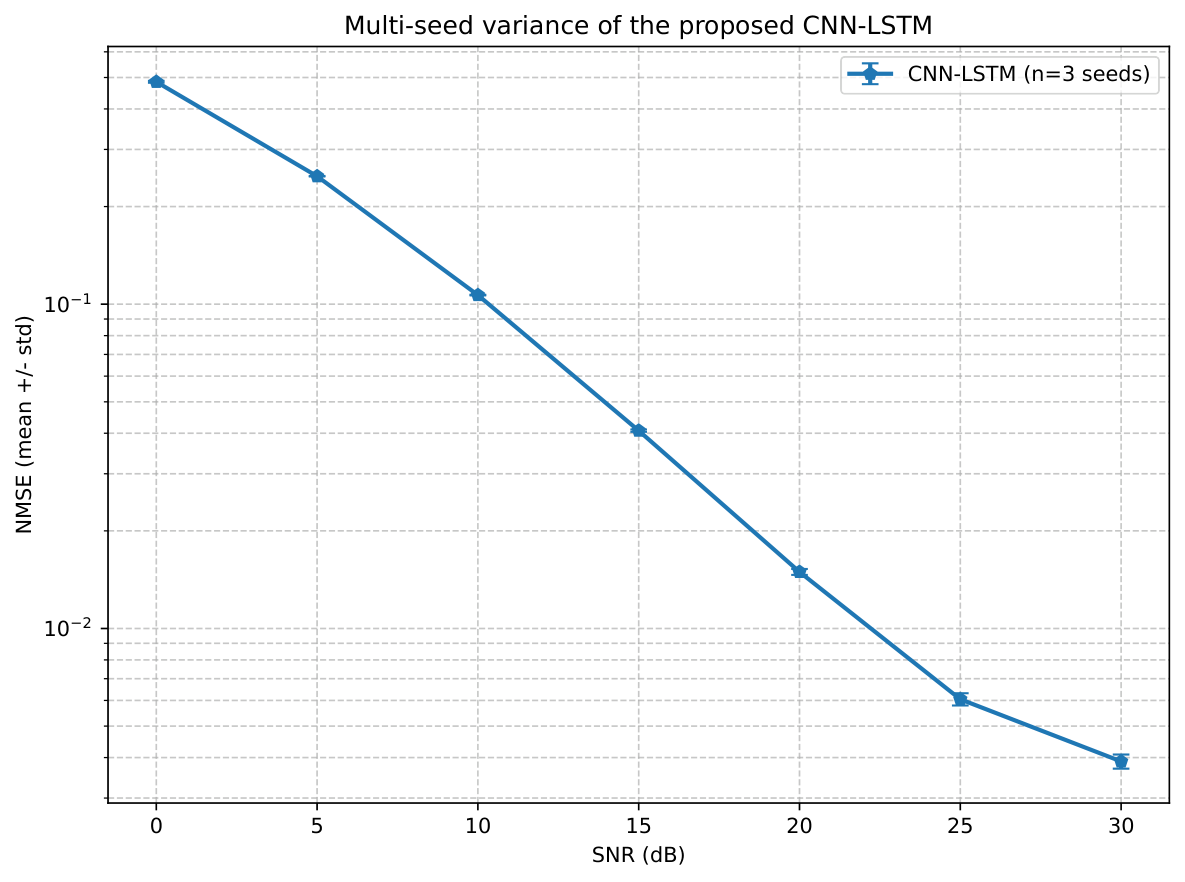


Fig11_training_curves.pdf


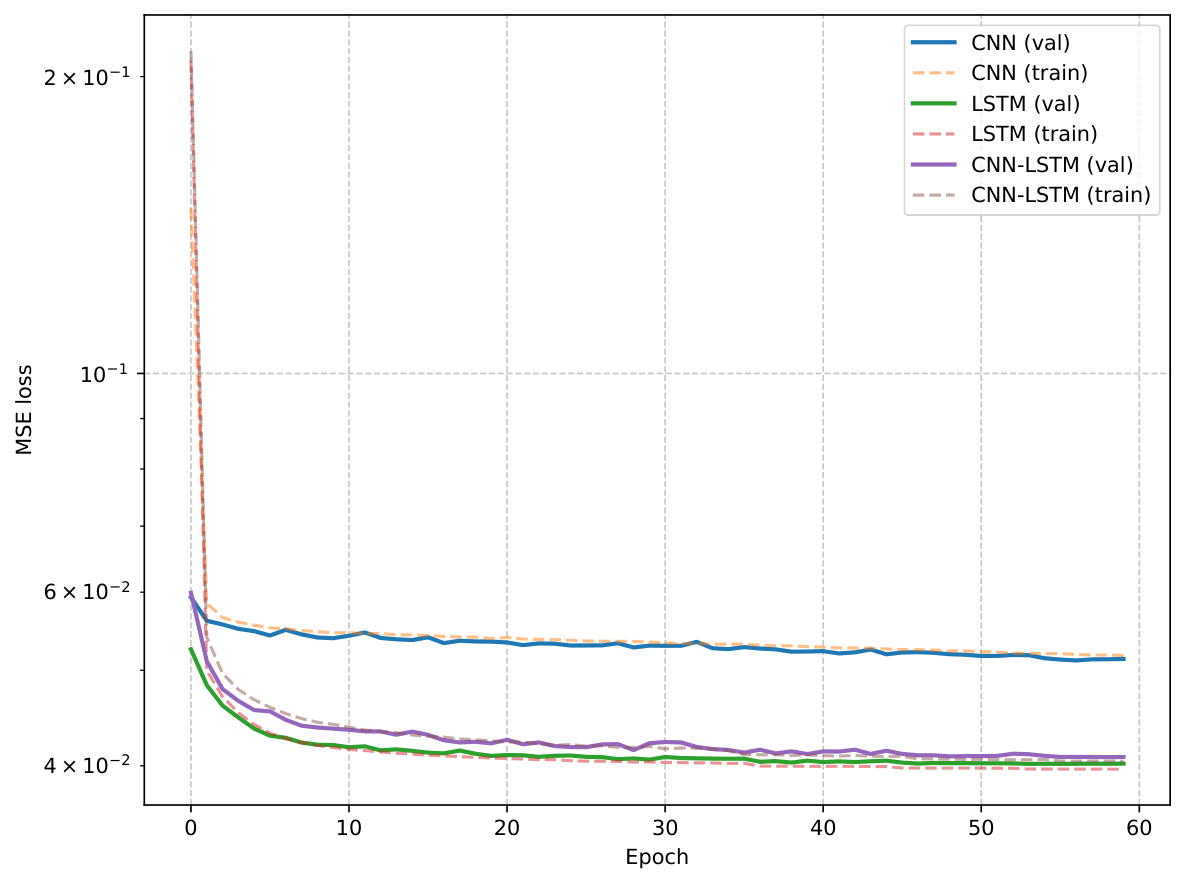


Fig12_nmse_2x2_vs_4x4.pdf


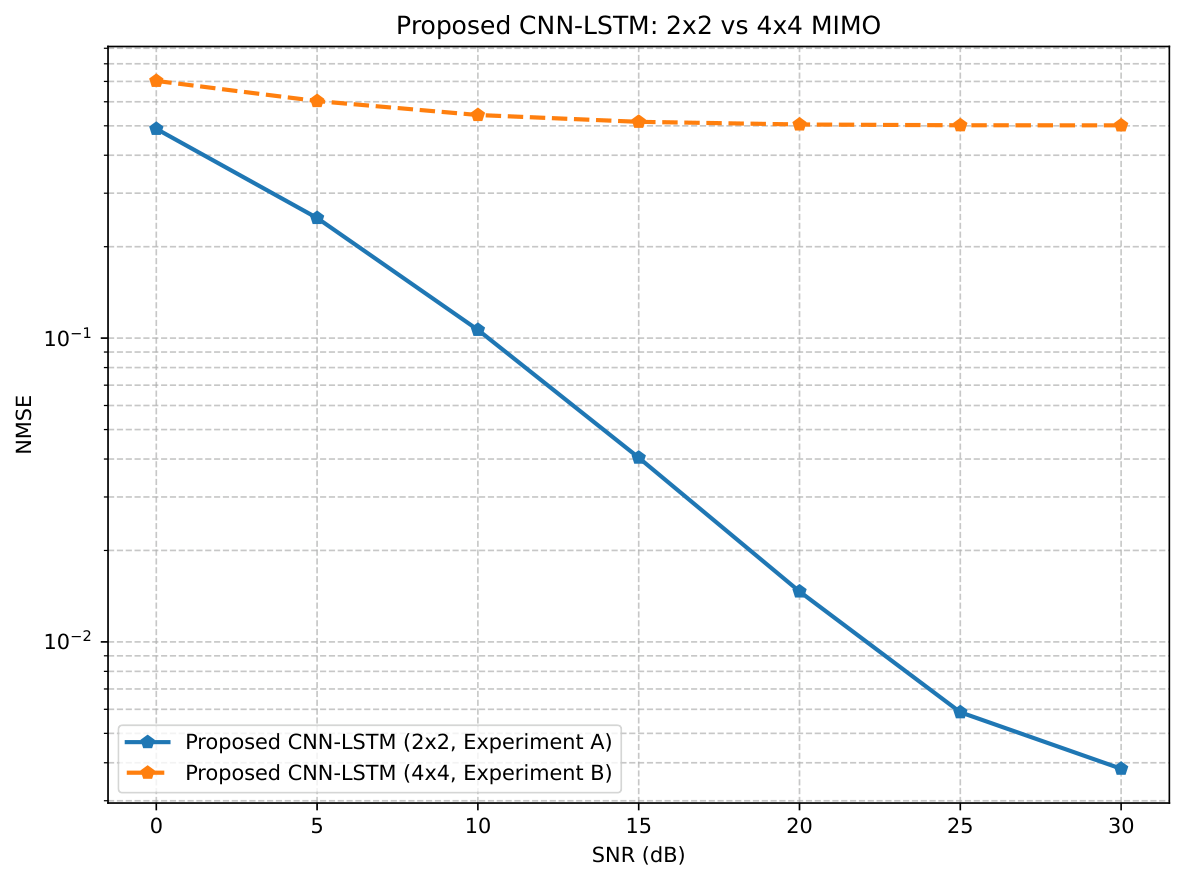


Fig1_system_model.pdf


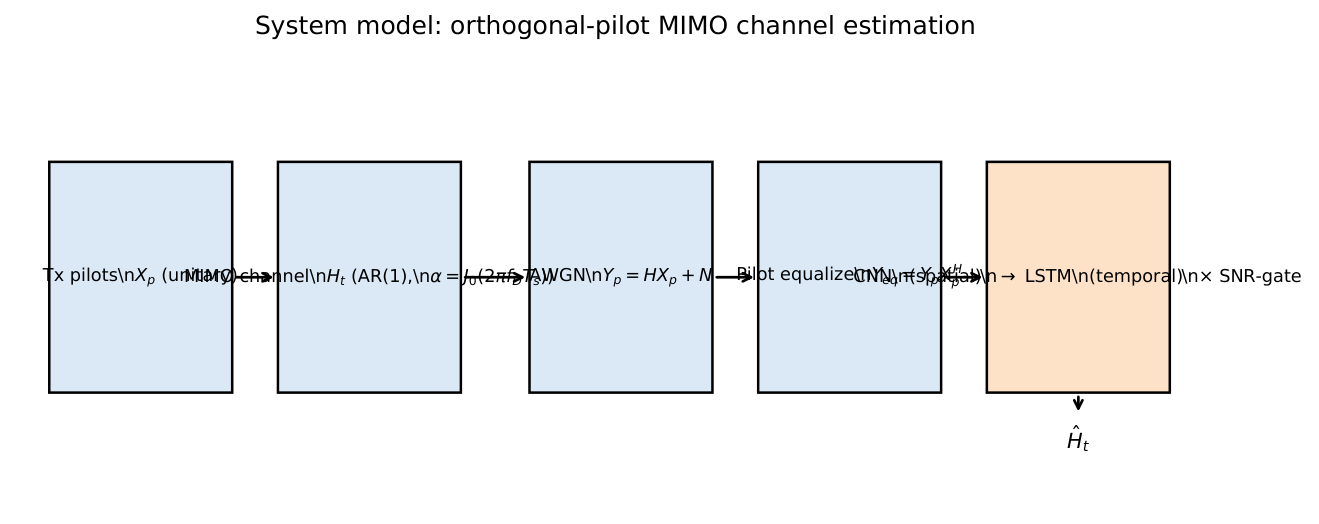


Fig2_NMSE.pdf


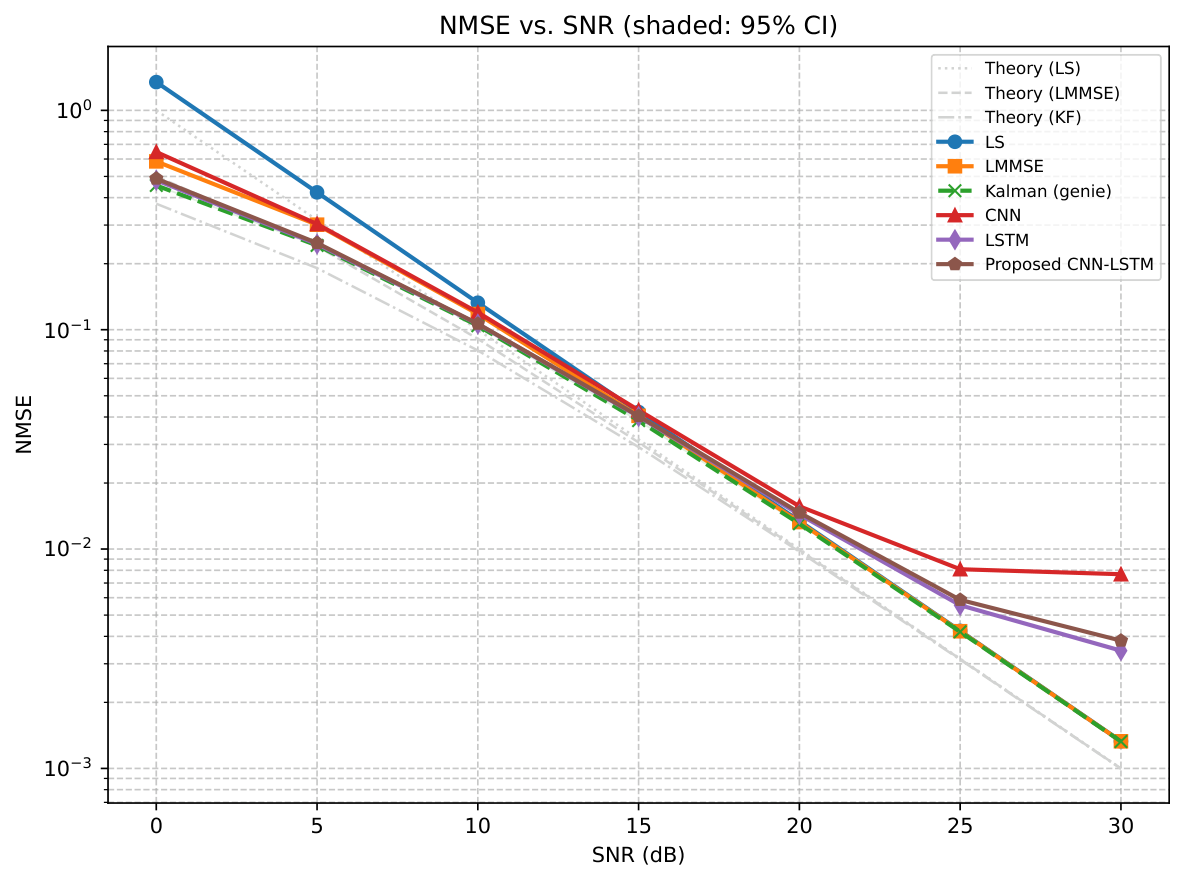


Fig2_NMSE_4x4.pdf


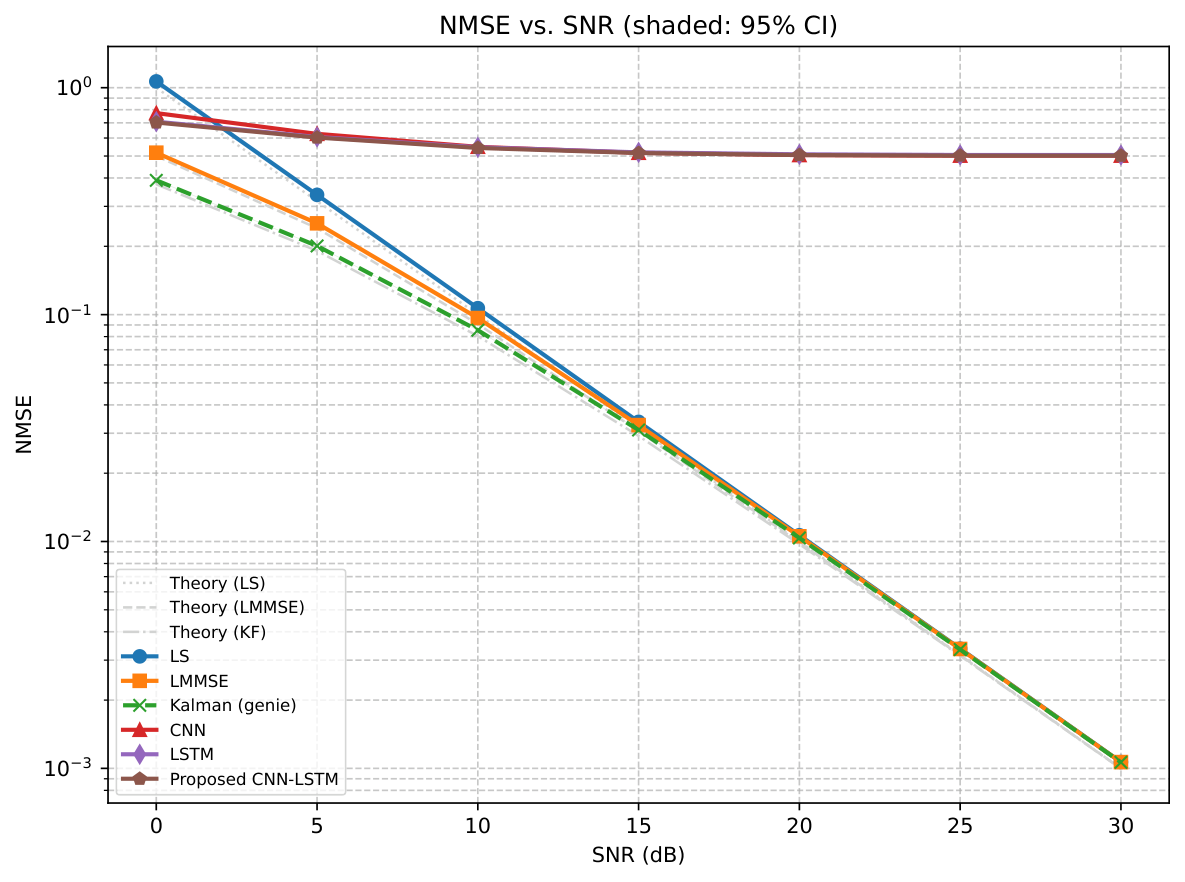


Fig3_BER.pdf


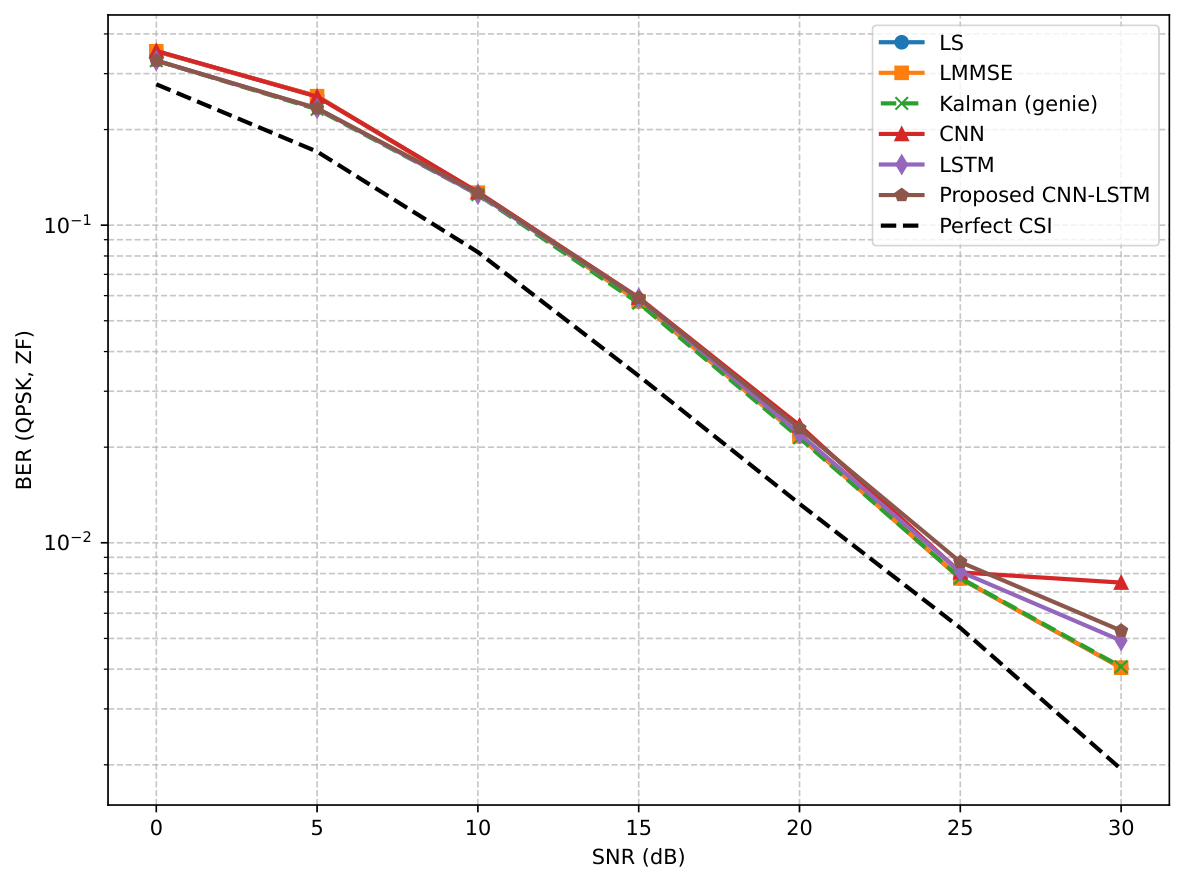


Fig3_BER_4x4.pdf


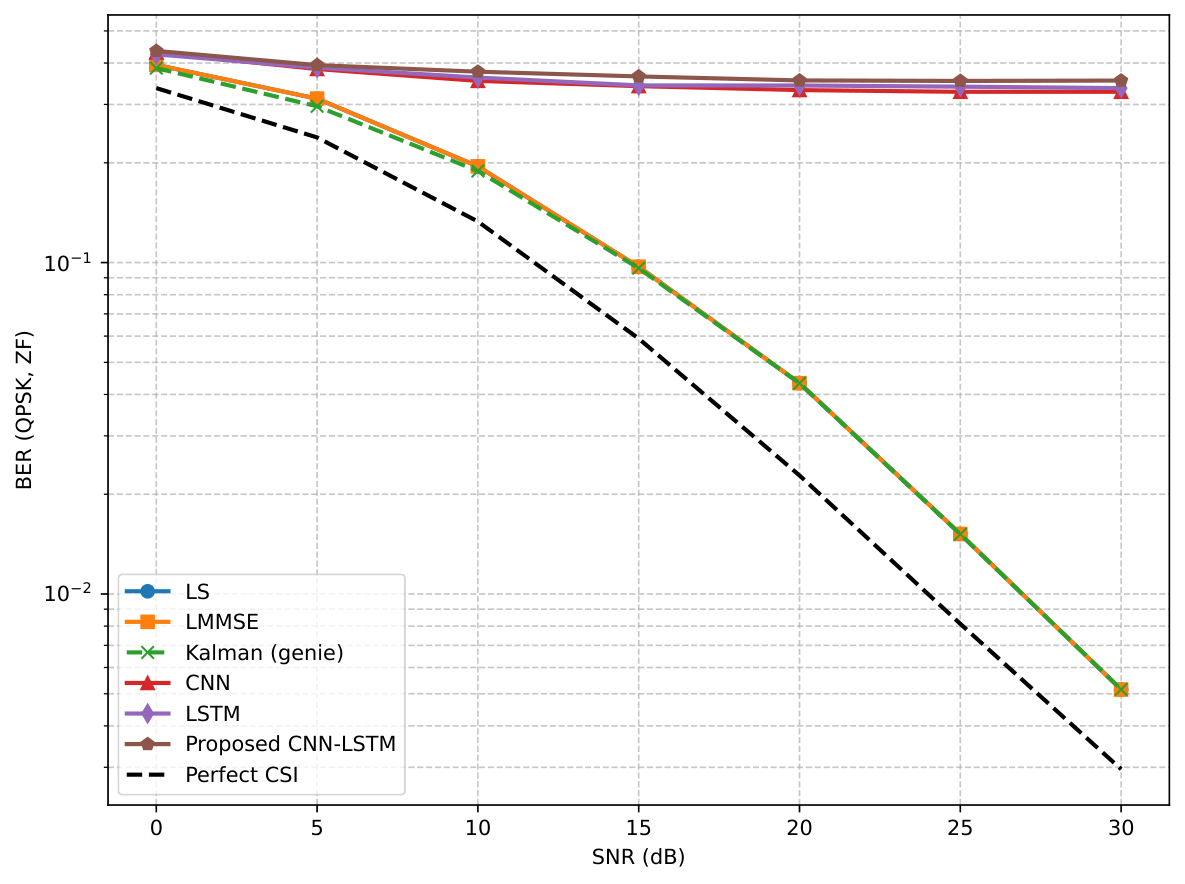


Fig4_ablation.pdf


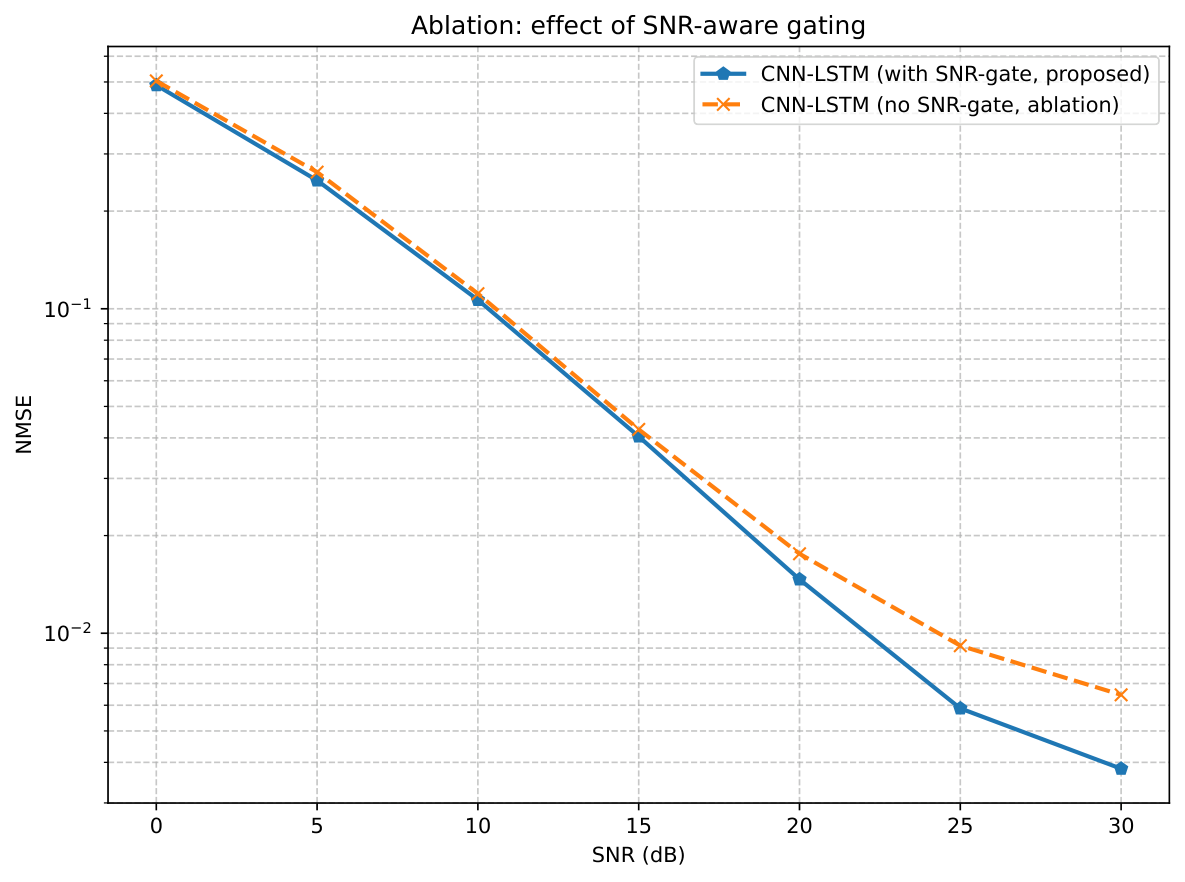


Fig5_alpha_robustness.pdf


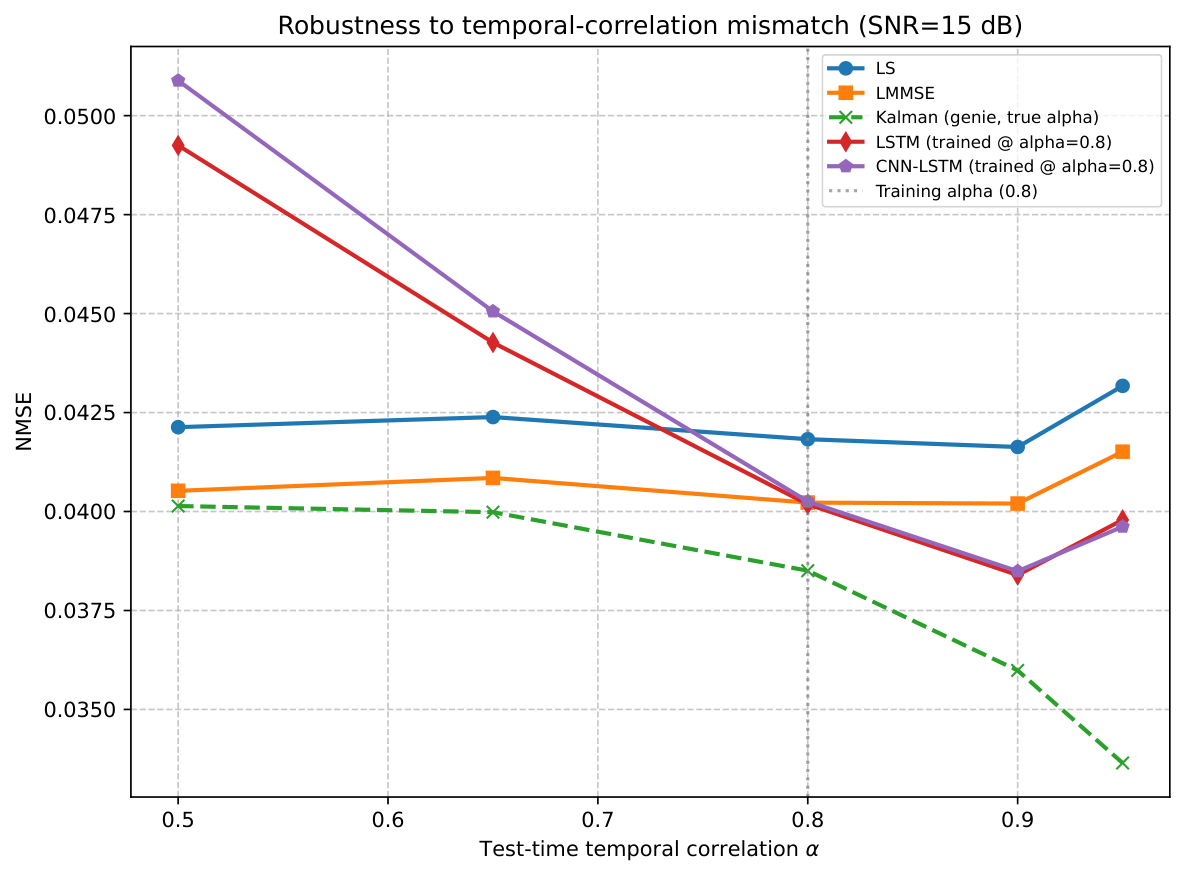


Fig6_complexity.pdf


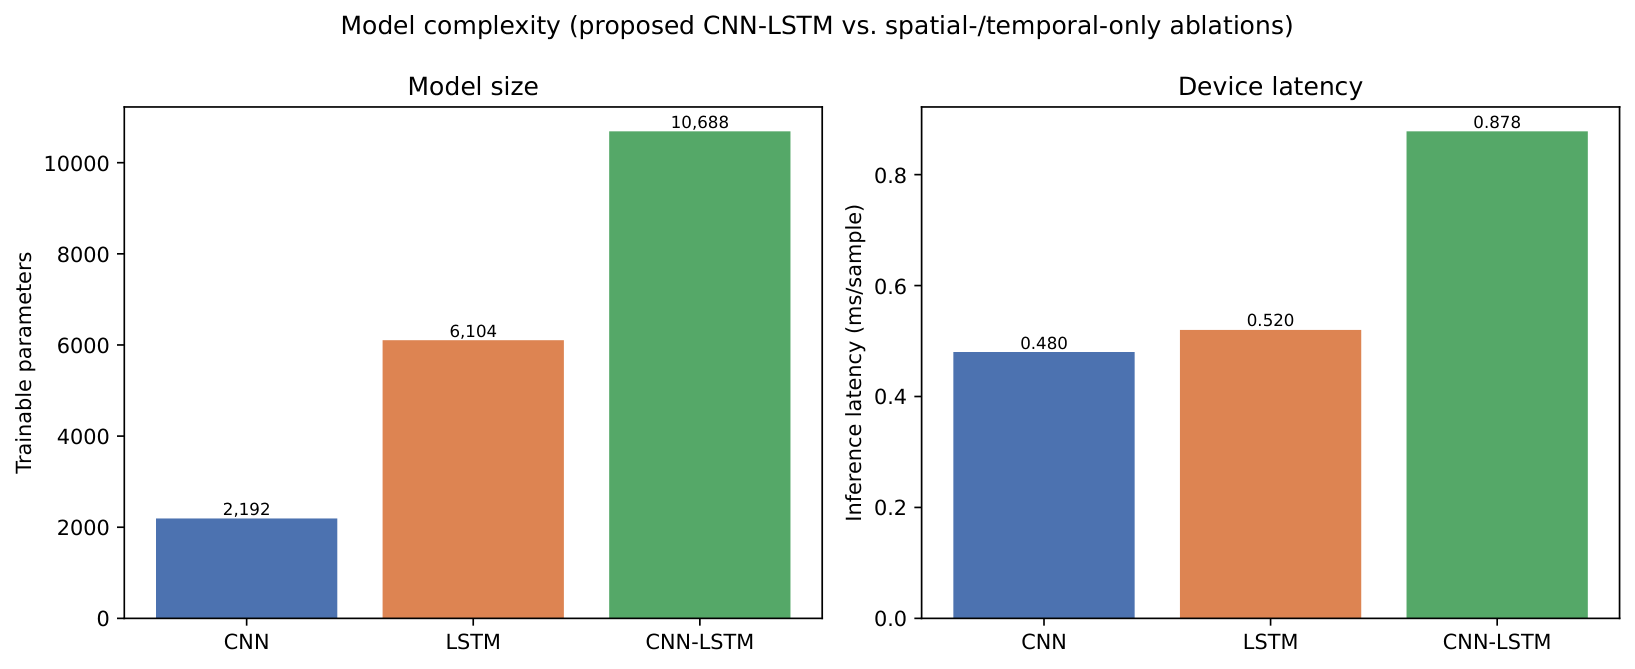


Fig6_complexity_4x4.pdf


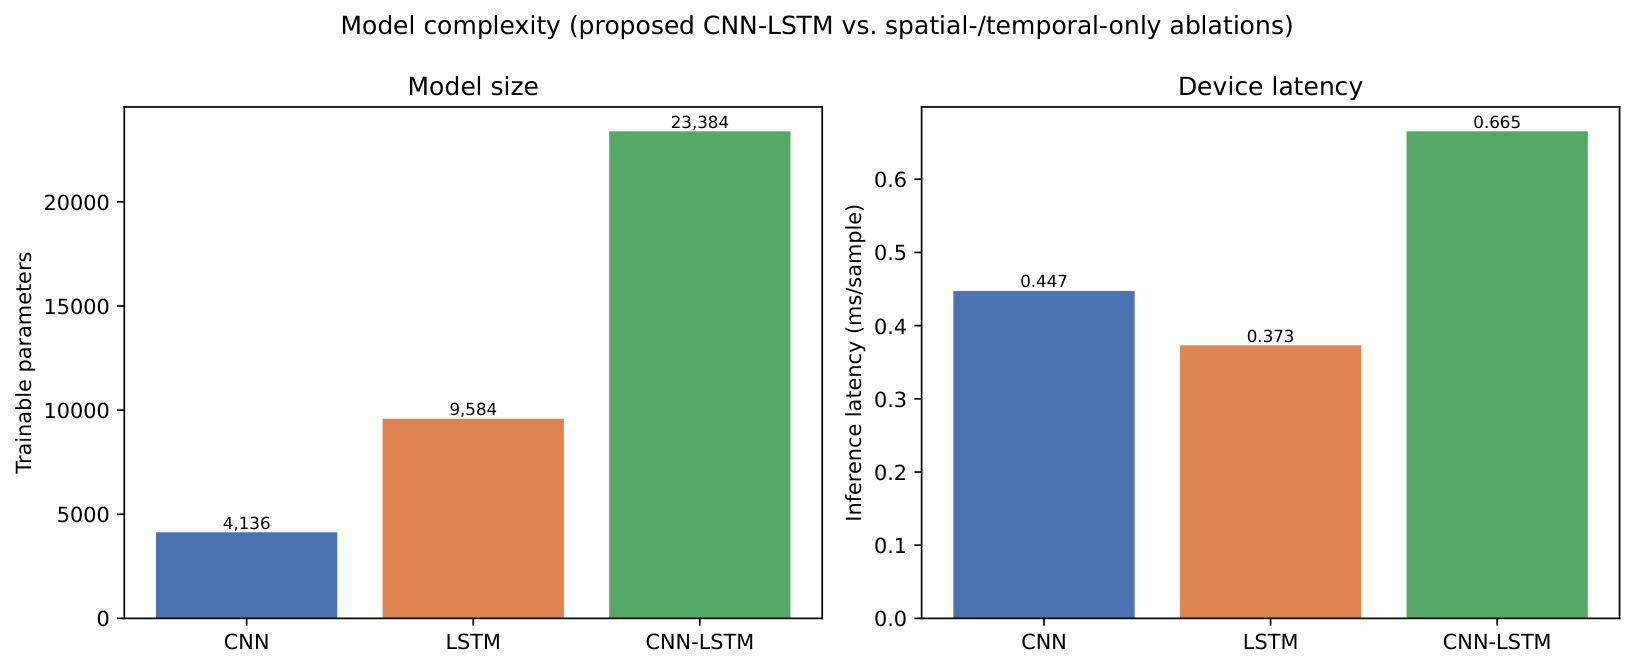


Fig7_spectral_efficiency.pdf


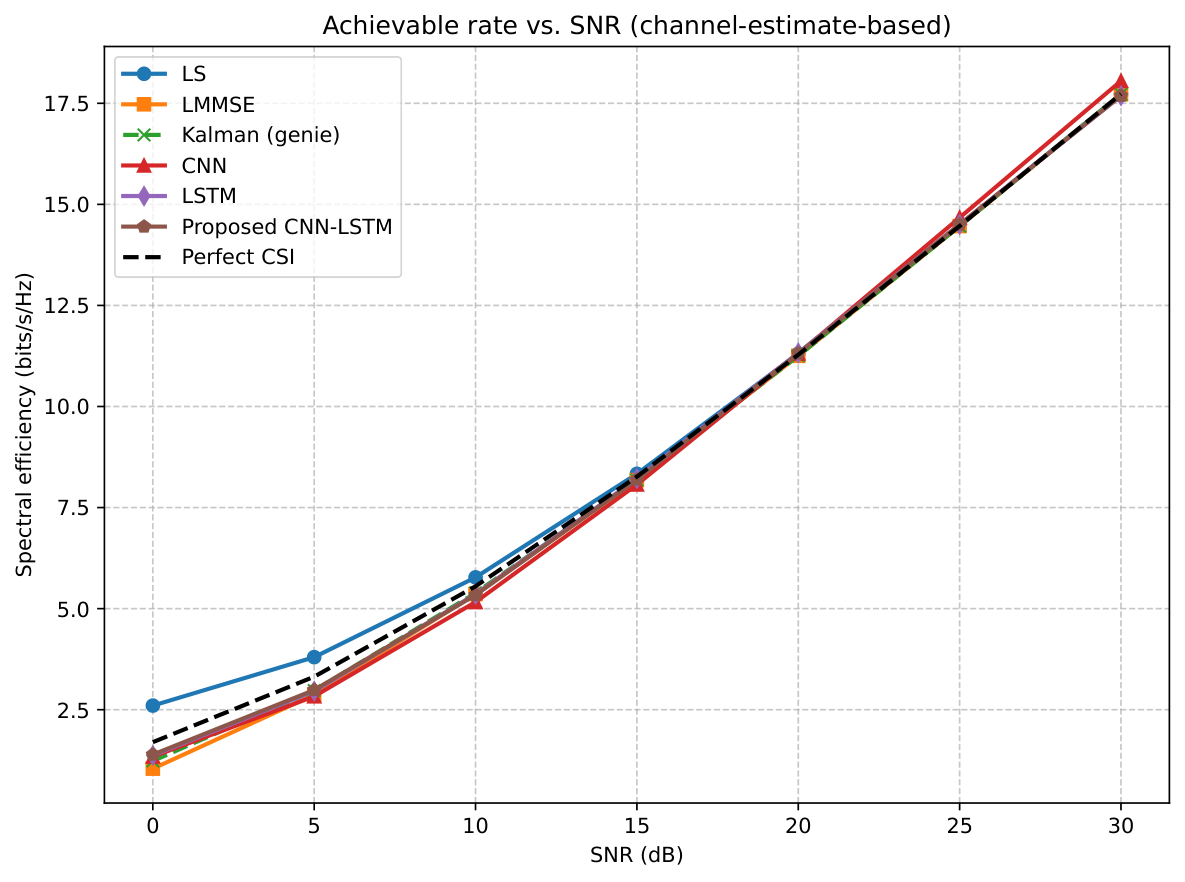


Fig8_seqlen_study.pdf


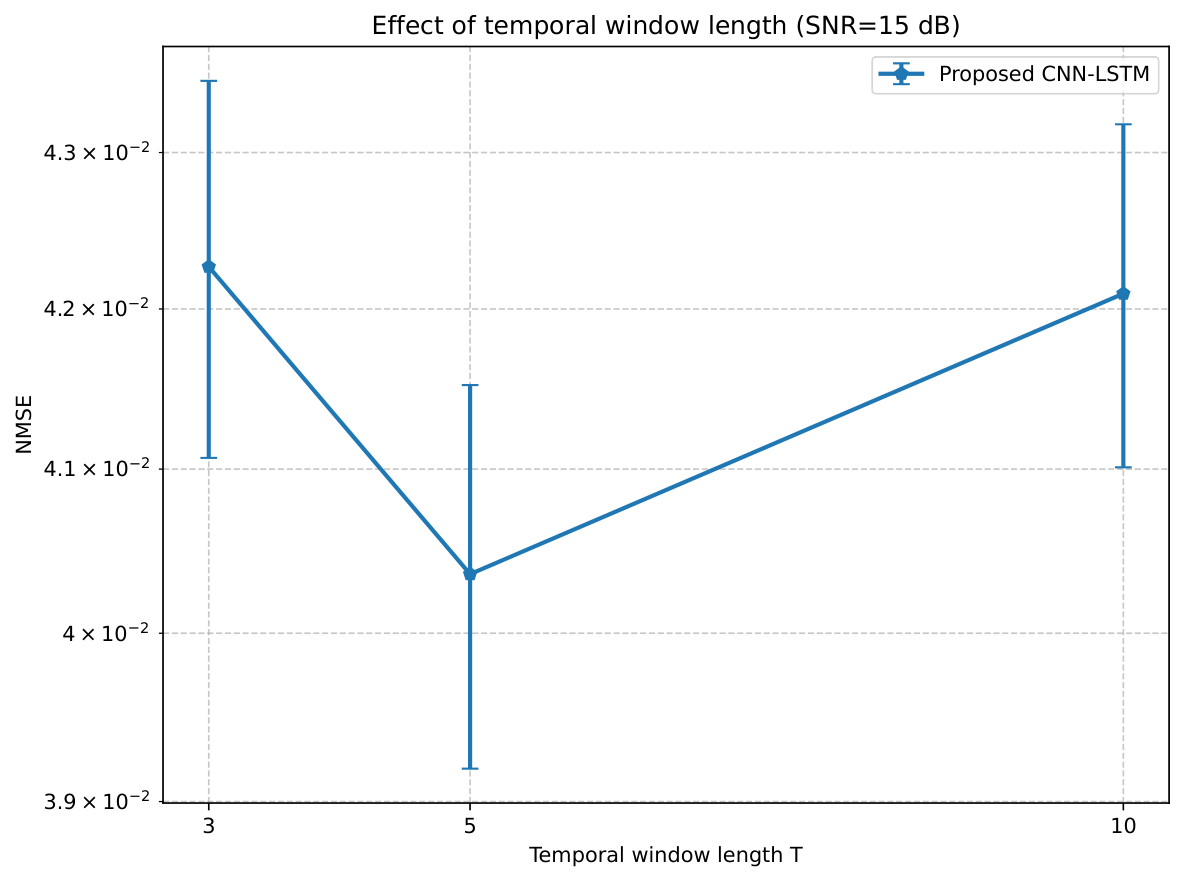


Fig9_spatial_correlation_robustness.pdf


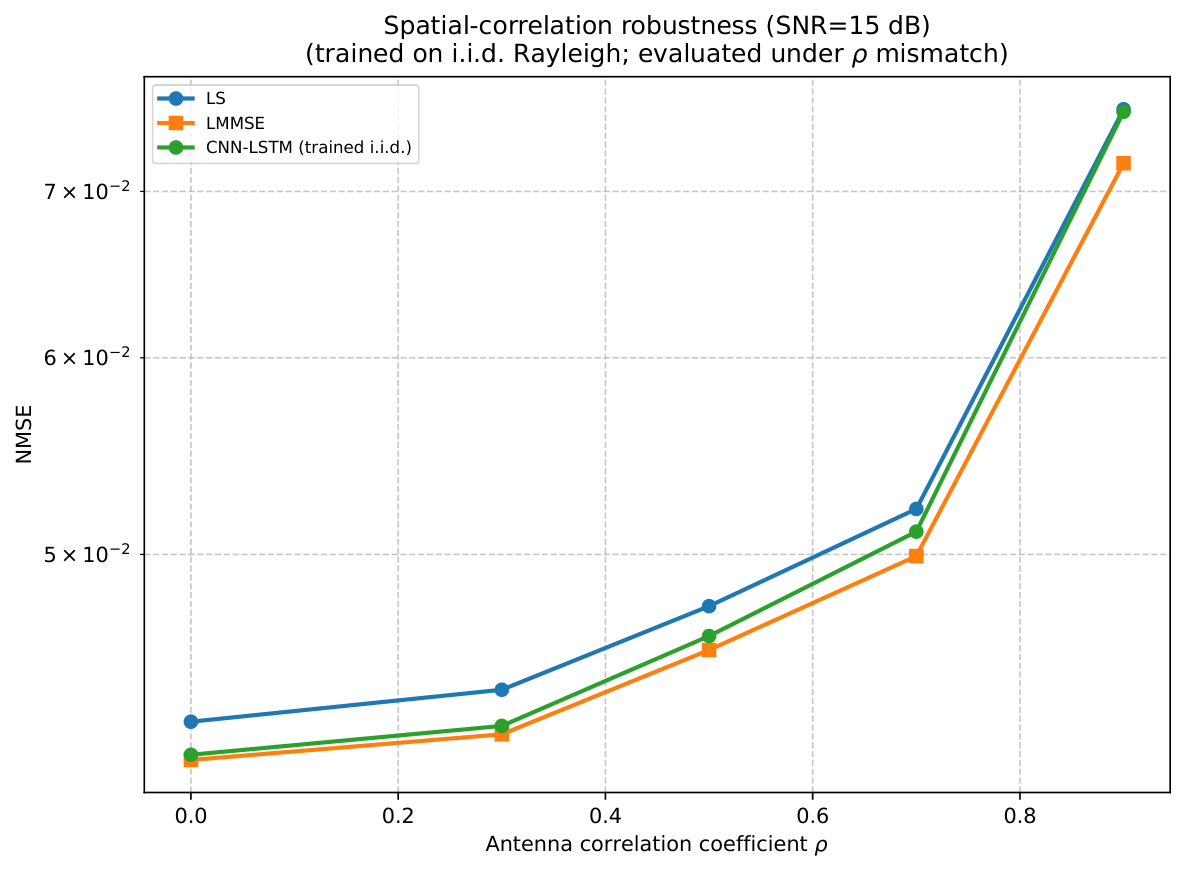

In [ ]:
# Render every generated Fig*.pdf inline in the notebook (Colab has no native
# PDF preview, so we rasterize each page to PNG with PyMuPDF).
!pip -q install pymupdf >/dev/null 2>&1
import fitz  # PyMuPDF
import glob
from IPython.display import display, Image as IPyImage

fig_files = sorted(glob.glob('./Figures/*.pdf'))
print(f"Found {len(fig_files)} figures in ./Figures/")

os.makedirs('./Figures_png', exist_ok=True)
for f in fig_files:
    doc = fitz.open(f)
    page = doc[0]
    pix = page.get_pixmap(dpi=150)
    out_png = os.path.join('./Figures_png', os.path.basename(f).replace('.pdf', '.png'))
    pix.save(out_png)
    doc.close()
    print(f"\n{os.path.basename(f)}")
    display(IPyImage(filename=out_png, width=650))


## 16. Inspect the key result tables

Quick look at the auto-generated NMSE/BER/complexity/final-summary tables (also available as `.csv` and `.tex`
inside `Paper_Data/`).

In [ ]:
import pandas as pd

print("=== Final results table (2x2, SNR=20dB) ===")
display(pd.read_csv('./results_2x2/final_results_table.csv'))

print("\n=== Experiment A (2x2) vs B (4x4) comparison ===")
display(pd.read_csv('./results_2x2/experiment_A_vs_B_2x2_4x4.csv'))

print("\n=== Model complexity (2x2) ===")
display(pd.read_csv('./results_2x2/complexity_results.csv'))

print("\n=== Model complexity (4x4) ===")
display(pd.read_csv('./results_4x4/complexity_results_4x4.csv'))

print("\n=== Train/test split & hyperparameters ===")
display(pd.read_csv('./results_2x2/train_test_split.csv'))


=== Final results table (2x2, SNR=20dB) ===


,Model,NMSE@20dB,BER@20dB,Parameters
0,LS,0.0134,0.02165,-
1,LMMSE,0.0133,0.02165,-
2,Kalman (genie),0.0130,0.02140,-
3,CNN,0.0157,0.02343,2192
4,LSTM,0.0144,0.02203,6104
5,CNN-LSTM,0.0147,0.02293,10688



=== Experiment A (2x2) vs B (4x4) comparison ===


,SNR_dB,NMSE_A,NMSE_B,BER_A,BER_B
0,0,0.4887,0.7029,0.329800,0.4353
1,5,0.2486,0.6032,0.233300,0.3945
2,10,0.1065,0.5428,0.126200,0.3768
3,15,0.0404,0.5154,0.059000,0.3646
4,20,0.0147,0.5052,0.022930,0.3545
5,25,0.0059,0.5021,0.008697,0.3534
6,30,0.0038,0.5017,0.005289,0.3542



=== Model complexity (2x2) ===


,Method,Parameters,FLOPs,Train_time_s,Latency_CPU_ms,Latency_device_ms
0,LS,-,-,-,0.0004,-
1,LMMSE,-,-,-,0.0018,-
2,Kalman (genie),-,-,-,0.0246,-
3,CNN,2192,12816,240.53,0.2078,0.4802
4,LSTM,6104,52544,249.82,0.5665,0.5201
5,CNN-LSTM,10688,140864,278.51,1.1045,0.8782



=== Model complexity (4x4) ===


,Method,Parameters,FLOPs,Train_time_s,Latency_CPU_ms,Latency_device_ms
0,LS,-,-,-,0.0003,-
1,LMMSE,-,-,-,0.0016,-
2,Kalman (genie),-,-,-,0.0217,-
3,CNN,4136,51216,208.76,0.1991,0.4474
4,LSTM,9584,84032,203.53,0.3411,0.3731
5,CNN-LSTM,23384,437312,257.93,0.7509,0.6655



=== Train/test split & hyperparameters ===


,Parameter,Value
0,Training samples,100000
1,Validation samples,20000
2,Testing samples,20000
3,Sequence length,5
4,SNR range (dB),0--30
5,SNR training range (dB),0--30
6,Optimizer,Adam
7,Learning rate,0.001
8,Epochs (max),60
9,Early-stopping patience,10


## 17. Package and download everything

Zips the full deliverable set — `results_2x2/`, `results_4x4/`, `plots_2x2/`, `plots_4x4/`,
`Paper_Data/` (CSV + LaTeX tables), and `Figures/` (the 12 publication PDFs) — and offers it as a
one-click download. Also copies the ZIP to `/mnt/user-data/outputs/` if that path exists (e.g. when
running inside a managed environment rather than plain Colab).

In [ ]:
import shutil

zip_base = 'CNN_LSTM_ChannelEstimation_full_results'
dirs_to_zip = ['results_2x2', 'results_4x4', 'plots_2x2', 'plots_4x4', 'Paper_Data', 'Figures']

staging = './_paper_bundle'
if os.path.exists(staging):
    shutil.rmtree(staging)
os.makedirs(staging)
for d in dirs_to_zip:
    if os.path.isdir(d):
        shutil.copytree(d, os.path.join(staging, d))

zip_path = shutil.make_archive(zip_base, 'zip', staging)
print("Created:", zip_path, f"({os.path.getsize(zip_path)/1e6:.1f} MB)")

# Colab: trigger a browser download
try:
    from google.colab import files
    files.download(zip_path)
except ImportError:
    print("Not running in Colab -- skip auto-download. The zip is at:", os.path.abspath(zip_path))

# If running in a workspace with /mnt/user-data/outputs, copy it there too
out_dir = '/mnt/user-data/outputs'
if os.path.isdir(out_dir):
    shutil.copy(zip_path, out_dir)
    print("Also copied to:", os.path.join(out_dir, os.path.basename(zip_path)))


Created: /content/CNN_LSTM_ChannelEstimation_full_results.zip (0.5 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
### Notes on reproducibility
- Every run seeds `numpy`/`torch`/`random` with `cfg['seed'] = 42` (see `seed_everything`), and the multi-seed
  study additionally retrains with seeds `123` and `2024` to report variance.
- `./results_*/config.json`, `environment.json`, and `random_seed.json` capture the exact hyperparameters,
  Python/PyTorch/CUDA versions, and GPU used for this run, for the paper's reproducibility statement.
- All 17 SNR/NMSE/BER/complexity numbers reported in the paper's tables are recomputed from scratch by this
  notebook — nothing is hard-coded.
